# **Wind Turbine Anomaly Detection with Autoencoder**

![Renewable Energy](https://www.acciona.com.au/content/dam/accionaau/media/igamrjsj/renewables.jpg)

## Introduction

This notebook investigates anomaly detection techniques across three different wind farms (A, B, and C). The objective is to identify unusual or potentially problematic behavior within each wind farm's operational data and compare the effectiveness of different anomaly detection models in diverse scenarios.

## Methodology

The analysis follows a consistent approach for each wind farm:

1. **Data Loading and Preprocessing:**
    - Raw data is loaded from CSV files specific to each wind farm.
    - Basic data exploration and preprocessing are performed, including handling missing values and splitting the data into training and testing sets.
    - Features are scaled using StandardScaler.

2. **Anomaly Detection Models:**
    - **Autoencoder (AE):** An autoencoder is trained to learn a compressed representation of normal data. Anomalies are detected by comparing the reconstruction error of data points.
    - **Error Prediction Model (ANN):** A separate artificial neural network is trained to predict reconstruction errors and improve anomaly detection thresholds.

3. **Evaluation:**
    - The CARE Score (Coverage, Accuracy, Reliability, Earliness) is calculated to assess the overall effectiveness of each model for each wind farm.

4. **Feature Selection with Random Forest:**
    - A Random Forest classifier is used to identify the most important features for anomaly detection.
    - Models are retrained using the top features for each wind farm.

5. **PCA Implementation:**
   - Principal Component Analysis (PCA) is applied for dimensionality reduction and potential model enhancement.
   - Anomaly detection models are trained and evaluated with PCA-transformed data for each wind farm.



## Setup and Imports

### Library Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


from pathlib import Path
import joblib
import os
import sys

from typing import List, Tuple, Dict, Union, Optional

In [ ]:
# Configuration de l'affichage
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [3]:
!cp /content/drive/MyDrive/GDM5\ project/care_score.py . # Copy the file care_score
import care_score
from care_score import CAREScore, AnomalyEvent, EventDetector, Coverage, Accuracy, Reliability, Earliness # Import necessary components

###  Configuration and Settings

##  Data Loading and Preprocessing

###  Data Loading

In [5]:
df = pd.read_parquet('/content/drive/MyDrive/GDM5 project/data/combined_data.parquet')
# Create a new column 'status_id' based on the values in 'status_type_id'.
# If 'status_type_id' is 0 or 2, assign 'normal'; otherwise, assign 'not normal'.
df['status_id'] = np.where(df['status_type_id'].isin([0, 2]), 'normal', 'not normal')
df['status_id'].value_counts()
normal_percentage = len(df[df['status_id'] == 'normal']) / len(df)
print(f"Percentage of normal data: {normal_percentage * 100:.2f}%")
# Select columns related to sensors, wind speed, and power.
sensor_columns = [col for col in df.columns if any(x in col for x in
                        ['sensor', 'wind_speed', 'power'])]

# Get the number of selected sensor columns.
len(sensor_columns)
print(f"number of selected sensor columns: {len(sensor_columns)}")

Percentage of normal data: 75.09%
number of selected sensor columns: 81


In [ ]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return lower_bound, upper_bound, outliers

# Liste de vos capteurs (celle-ci est extraite de votre message)
sensor_columns = [
    'sensor_0_avg', 'sensor_1_avg', 'sensor_2_avg',
    'wind_speed_3_avg', 'wind_speed_4_avg', 'wind_speed_3_max',
    'wind_speed_3_min', 'wind_speed_3_std', 'sensor_5_avg', 'sensor_5_max',
    'sensor_5_min', 'sensor_5_std', 'sensor_6_avg', 'sensor_7_avg',
    'sensor_8_avg', 'sensor_9_avg', 'sensor_10_avg', 'sensor_11_avg',
    'sensor_12_avg', 'sensor_13_avg', 'sensor_14_avg', 'sensor_15_avg',
    'sensor_16_avg', 'sensor_17_avg', 'sensor_18_avg', 'sensor_18_max',
    'sensor_18_min', 'sensor_18_std', 'sensor_19_avg', 'sensor_20_avg',
    'sensor_21_avg', 'sensor_22_avg', 'sensor_23_avg', 'sensor_24_avg',
    'sensor_25_avg', 'sensor_26_avg', 'reactive_power_27_avg',
    'reactive_power_27_max', 'reactive_power_27_min',
    'reactive_power_27_std', 'reactive_power_28_avg',
    'reactive_power_28_max', 'reactive_power_28_min',
    'reactive_power_28_std', 'power_29_avg', 'power_29_max', 'power_29_min',
    'power_29_std', 'power_30_avg', 'power_30_max', 'power_30_min',
    'power_30_std', 'sensor_31_avg', 'sensor_31_max', 'sensor_31_min',
    'sensor_31_std', 'sensor_32_avg', 'sensor_33_avg', 'sensor_34_avg',
    'sensor_35_avg', 'sensor_36_avg', 'sensor_37_avg', 'sensor_38_avg',
    'sensor_39_avg', 'sensor_40_avg', 'sensor_41_avg', 'sensor_42_avg',
    'sensor_43_avg', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47',
    'sensor_48', 'sensor_49', 'sensor_50', 'sensor_51', 'sensor_52_avg',
    'sensor_52_max', 'sensor_52_min', 'sensor_52_std', 'sensor_53_avg'
]

# On parcourt chaque capteur et on collecte les infos sur les outliers
outlier_summary = []

for col in sensor_columns:
    if col in df.columns:
        lower, upper, outliers = detect_outliers_iqr(df, col)
        num_outliers = len(outliers)
        total = len(df)
        percentage = (num_outliers / total) * 100
        outlier_summary.append({
            'capteur': col,
            'lower_bound': lower,
            'upper_bound': upper,
            'num_outliers': num_outliers,
            'percentage': percentage
        })
        print(f"Capteur {col} : {num_outliers} outliers ({percentage:.2f}%) - bornes: {lower:.2f} à {upper:.2f}")
    else:
        print(f"Capteur {col} non trouvé dans le DataFrame.")

# On peut transformer ce résumé en DataFrame pour une analyse plus facile
summary_df = pd.DataFrame(outlier_summary)
print("\nRésumé des outliers par capteur:")
print(summary_df)
#sorted summaryy_df by percentage
summary_df = summary_df.sort_values(by='percentage', ascending=False)
print("\nRésumé des outliers par capteur (trié):")
print(summary_df)
# Optionnel : Afficher un boxplot pour les capteurs présentant un pourcentage élevé d'outliers (par exemple, > 5%)
threshold = 50  # seuil en pourcentage
for idx, row in summary_df.iterrows():
    if row['percentage'] > threshold:
        plt.figure(figsize=(6,4))
        plt.boxplot(df[row['capteur']])
        plt.title(f"Boxplot de {row['capteur']} ({row['percentage']:.2f}% outliers)")
        plt.show()


Capteur sensor_0_avg : 3105 outliers (0.26%) - bornes: 4.00 à 36.00
Capteur sensor_1_avg : 0 outliers (0.00%) - bornes: -145.40 à 503.40
Capteur sensor_2_avg : 125465 outliers (10.48%) - bornes: -38.20 à 37.80
Capteur wind_speed_3_avg : 15075 outliers (1.26%) - bornes: -4.75 à 16.45
Capteur wind_speed_4_avg : 12277 outliers (1.03%) - bornes: -4.60 à 16.20
Capteur wind_speed_3_max : 13483 outliers (1.13%) - bornes: -9.30 à 33.90
Capteur wind_speed_3_min : 17570 outliers (1.47%) - bornes: -2.00 à 5.20
Capteur wind_speed_3_std : 30661 outliers (2.56%) - bornes: -0.65 à 2.95
Capteur sensor_5_avg : 40016 outliers (3.34%) - bornes: -40.25 à 62.55
Capteur sensor_5_max : 60102 outliers (5.02%) - bornes: -35.50 à 59.70
Capteur sensor_5_min : 37860 outliers (3.16%) - bornes: -36.90 à 55.10
Capteur sensor_5_std : 186177 outliers (15.56%) - bornes: -1.40 à 2.60
Capteur sensor_6_avg : 14818 outliers (1.24%) - bornes: 15.50 à 43.50
Capteur sensor_7_avg : 6599 outliers (0.55%) - bornes: 23.00 à 55.00

In [117]:
# Calculate the proportion of 'train' and 'prediction' in the original DataFrame
train_proportion = df['train_test'].value_counts(normalize=True)['train']
prediction_proportion = df['train_test'].value_counts(normalize=True)['prediction']

# Calculate the number of samples for 'train' and 'prediction' in the 10,000 lines
num_train_samples = int(10000 * train_proportion)
num_prediction_samples = int(10000 * prediction_proportion)

# Randomly sample data for 'train' and 'prediction' separately
train_df = df[df['train_test'] == 'train'].sample(n=num_train_samples, random_state=42)  # Use random_state for reproducibility
prediction_df = df[df['train_test'] == 'prediction'].sample(n=num_prediction_samples, random_state=42)

# Concatenate the sampled DataFrames
sampled_df = pd.concat([train_df, prediction_df])
df = sampled_df
# Now 'sampled_df' contains 10,000 randomly selected lines
# with the same proportion of 'train' and 'prediction' as the original DataFrame

### Data Preprocessing

##  Model Architecture

###  Autoencoder Model

In [6]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=4, is_pca_data=False):
        super(Autoencoder, self).__init__()
        torch.manual_seed(42)

        if is_pca_data:
            # Architecture simplifiée pour les données PCA
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 6),
                nn.BatchNorm1d(6),
                nn.LeakyReLU(negative_slope=0.05),
                nn.Dropout(0.2),
                nn.Linear(6, encoding_dim),
                nn.LeakyReLU(negative_slope=0.05)
            )
            self.decoder = nn.Sequential(
                nn.Linear(encoding_dim, 6),
                nn.BatchNorm1d(6),
                nn.ReLU(),
                nn.Linear(6, input_dim)
                # Pas d'activation finale pour conserver une sortie linéaire
            )
        else:
            # Architecture complète pour les données brutes
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 44),
                nn.ReLU(),
                nn.Linear(44, 25),
                nn.ReLU(),
                nn.Linear(25, encoding_dim),  # Couche latente
                nn.LeakyReLU()
            )
            self.decoder = nn.Sequential(
                nn.Linear(encoding_dim, 25),
                nn.ReLU(),
                nn.Linear(25, 44),
                nn.ReLU(),
                nn.Linear(44, input_dim)
                # Sortie linéaire afin d'être compatible avec des données normalisées (centrées et réduites)
            )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded




###  RE Predictor Model

In [7]:
class REPredictor(nn.Module):
    """Neural Network for predicting Reconstruction Error, adapted from the paper.
       Architecture : input_dim -> 23 -> 1, avec activation ReLU en sortie.
    """
    def __init__(self, input_dim, hidden_dim=23, is_pca_data=False):
        super(REPredictor, self).__init__()
        torch.manual_seed(42)

        # Architecture identique pour PCA ou non, d'après le papier
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()

        # Optionnel : dropout léger, ici fixé à 0.1
        self.dropout = nn.Dropout(0.1)

        # Initialisation des poids avec Xavier pour de bonnes conditions de départ
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)

        self.is_pca_data = is_pca_data

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.relu(x)  # On s'assure que la sortie soit positive
        return x


##  Training

### Model Training

In [8]:
def preprocess_data(df, is_pca_data=False, scaler=None):
    """
    Prétraitement des données: sélection et normalisation des capteurs

    Args:
        df: DataFrame contenant les données des capteurs
        is_pca_data: Indique si les données sont déjà transformées par PCA
        scaler: Scaler préexistant à utiliser (optionnel)

    Returns:
        X_scaled: Données normalisées
        sensor_columns: Noms des colonnes sélectionnées
        scaler: Le scaler utilisé (nouveau ou existant)
    """
    # Si les données sont déjà transformées par PCA, utiliser toutes les colonnes numériques
    if is_pca_data:
        # Sélectionner uniquement les colonnes PC
        sensor_columns = [col for col in df.columns if col.startswith('PC')]
        if not sensor_columns:
            raise ValueError("Aucune colonne PC trouvée dans les données PCA")

        # Pour les données PCA, pas besoin de normaliser à nouveau
        X = df[sensor_columns].copy()
        return X.values, sensor_columns, scaler
    else:
        # Sélection des colonnes pertinentes (capteurs uniquement)
        sensor_columns = [col for col in df.columns if any(x in col for x in
                        ['sensor', 'wind_speed', 'power'])]

        print(f"Nombre de capteurs sélectionnés: {len(sensor_columns)}")

        if len(sensor_columns) == 0:
            raise ValueError("Aucune colonne de capteur trouvée dans les données")

        # Vérification et nettoyage des données
        X = df[sensor_columns].copy()

        # Remplacer les valeurs infinies par NaN
        X.replace([np.inf, -np.inf], np.nan, inplace=True)

        # Fill NaN with column means
        X.fillna(X.mean(), inplace=True)
        # X.dropna(inplace=True)

        # Normalisation des caractéristiques
        if scaler is None:
            # Créer un nouveau scaler et l'ajuster aux données
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
        else:
            # Utiliser le scaler existant (pour les données de test)
            X_scaled = scaler.transform(X)

        return X_scaled, sensor_columns, scaler

### WindTurbineAnomalyDetector

In [17]:
class WindTurbineAnomalyDetector:
    """
    Détecteur d'anomalies pour les éoliennes utilisant un autoencoder.
    """

    def __init__(self, encoding_dim=4, hidden_dim=23, gamma=0.344):
        """
        Initialise le détecteur d'anomalies.

        Args:
            encoding_dim: Dimension de la couche d'encodage
            hidden_dim: Dimension de la couche cachée
            gamma: Paramètre gamma pour le calcul du seuil d'anomalie
        """
        self.encoding_dim = encoding_dim
        self.hidden_dim = hidden_dim
        self.gamma = gamma
        self.model = None
        self.re_predictor = None
        self.scaler = None
        self.pca = None
        self.threshold = None
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Utilisation de: {self.device}")

    def preprocess_data(self, df, is_pca_data=False):
        """
        Prétraite les données pour l'autoencoder.

        Args:
            df: DataFrame contenant les données
            is_pca_data: Indique si les données sont déjà transformées par PCA

        Returns:
            X_scaled: Données normalisées
            feature_columns: Noms des colonnes utilisées
        """
        # Utiliser la fonction externe avec notre scaler
        X_scaled, sensor_columns, self.scaler = preprocess_data(
            df,
            is_pca_data=is_pca_data,
            scaler=self.scaler
        )

        return X_scaled, sensor_columns

    def build_model(self, input_dim):
          """
          Construit le modèle d'autoencoder.

          Args:
              input_dim: Dimension d'entrée (nombre de features)

          Returns:
              Modèle d'autoencoder
          """
          # Utiliser la classe Autoencoder définie globalement
          return Autoencoder(
              input_dim=input_dim,
              encoding_dim=self.encoding_dim,
              is_pca_data=self.pca is not None
          ).to(self.device)

    def build_re_predictor(self, input_dim):
          """
          Construit le modèle de prédiction d'erreur de reconstruction.

          Args:
              input_dim: Dimension d'entrée (nombre de features)

          Returns:
              Modèle de prédiction d'erreur
          """
          # Utiliser la classe REPredictor définie globalement
          return REPredictor(
              input_dim=input_dim,
              hidden_dim=self.hidden_dim,
              is_pca_data=self.pca is not None
          ).to(self.device)

    def train(self, train_data, validation_data, epochs=100, batch_size=64,
              learning_rate=0.001, checkpoint_dir=None, is_pca_data=False):
        """
        Entraîne l'autoencoder sur les données fournies.

        Args:
            train_data: DataFrame contenant les données d'entraînement
            validation_data: DataFrame contenant les données de validation
            epochs: Nombre d'époques d'entraînement
            batch_size: Taille des batchs
            learning_rate: Taux d'apprentissage
            checkpoint_dir: Répertoire pour sauvegarder les checkpoints
            is_pca_data: Indique si les données sont déjà transformées par PCA

        Returns:
            losses: Liste des pertes d'entraînement
            validation_losses: Liste des pertes de validation
        """

            # Vérification des données reçues par train
        print("\n--- Données reçues par train ---")
        print(f"train_data shape: {train_data.shape}")
        print(f"train_data colonnes: {train_data.columns.tolist()}")
        print(f"train_data statistiques: \n{train_data.describe().loc[['mean', 'std']].round(4)}")
            # Afficher si on utilise des données PCA ou non
        print(f"Entraînement avec données PCA: {is_pca_data}")

        # Vérifier les colonnes pour confirmer
        if is_pca_data:
            pc_cols = [col for col in train_data.columns if col.startswith('PC')]
            print(f"Colonnes PCA détectées: {len(pc_cols)}")
            print(f"Exemples: {pc_cols[:3]}")

        # Prétraitement des données
        # X_train, feature_columns = self.preprocess_data(train_data, is_pca_data=is_pca_data)
        # X_val, _ = self.preprocess_data(validation_data, is_pca_data=is_pca_data)
    # Prétraitement des données
    # Récupère directement les données scalées de run_analysis
        features = [col for col in train_data.columns if any(x in col for x in
                            ['sensor', 'wind_speed', 'power'])]
        X_train = train_data[features].values.astype(np.float32)
        X_val = validation_data[features].values.astype(np.float32)
        print("\n--- Données après conversion en numpy dans train ---")
        print(f"X_train shape: {X_train.shape}")
        print(f"X_train statistiques: \nMoyenne={np.mean(X_train, axis=0).round(4)[:5]}...\nÉcart-type={np.std(X_train, axis=0).round(4)[:5]}...")
        print()
        print()
        print()
        print()
        print(f"Train data shape in train function: {train_data[features].shape}, columns: {train_data[features].columns}")
        print(f"Val data shape in train function: {validation_data[features].shape}, columns: {validation_data[features].columns}")
        print()
        print()
        print()
        print()
        # Vérifier la normalisation
        print(f"Vérification scaling - Moyenne train: {X_train.mean():.4f}, Écart-type: {X_train.std():.4f}")

            # Vérification des statistiques des données
        #print(f"Statistiques des données d'entraînement: Min={X_train.min():.4f}, Max={X_train.max():.4f}, Moyenne={X_train.mean():.4f}, Écart-type={X_train.std():.4f}")
        #print(f"Statistiques des données de validation: Min={X_val.min():.4f}, Max={X_val.max():.4f}, Moyenne={X_val.mean():.4f}, Écart-type={X_val.std():.4f}")

        # Conversion en tenseurs PyTorch
        X_train_tensor = torch.FloatTensor(X_train).to(self.device)
        X_val_tensor = torch.FloatTensor(X_val).to(self.device)

        # Datasets et DataLoaders
        train_dataset = TensorDataset(X_train_tensor, X_train_tensor)  # Les entrées = sorties attendues
        val_dataset = TensorDataset(X_val_tensor, X_val_tensor)  # Les entrées = sorties attendues

        # Utiliser un générateur avec une graine fixe pour la reproductibilité
        g = torch.Generator()
        g.manual_seed(42)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

                # Construction du modèle si nécessaire
        if self.model is None:
            input_dim = X_train.shape[1]
            self.model = Autoencoder(input_dim, self.encoding_dim, is_pca_data=is_pca_data).to(self.device)
            print(f"Modèle créé avec {input_dim} entrées et dimension latente de {self.encoding_dim}")

        # Fonction de perte et optimiseur
        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)
        best_val_loss = float('inf')
        early_stopping_counter = 0

        # Initialisation des listes pour stocker les pertes
        losses = []
        validation_losses = []

        # Boucle d'entraînement
        print("Début de l'entraînement...")
        prev_grad_norm = None
        for epoch in range(epochs):
            # MODE ENTRAÎNEMENT
            self.model.train()
            train_loss = 0
            batch_counter = 0
            for batch_features, _ in train_loader:
                # Forward pass
                batch_counter += 1
                outputs = self.model(batch_features)
                loss = criterion(outputs, batch_features)

                # Vérification de la perte
                if torch.isnan(loss):
                    print(f"Alerte: Perte NaN détectée à l'époque {epoch+1}. Arrêt de l'entraînement.")
                    return losses, validation_losses

                # Backward pass et optimisation
                optimizer.zero_grad()
                loss.backward()

                # Clip des gradients pour éviter l'explosion
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

                total_grad_norm = 0
                for param in self.model.parameters():
                    if param.grad is not None:
                        total_grad_norm += param.grad.norm().item()

                # print(f'Gradient norm: {total_grad_norm:.2f}')
                # Détection des changements brutaux (seuil à 50%)
                if prev_grad_norm is not None:
                    grad_change = abs((total_grad_norm - prev_grad_norm)/prev_grad_norm) * 100
                    if grad_change > 1000:
                        print(f'[Batch {batch_counter}] Changement brutal: '
                              f'{grad_change:.1f}% ({prev_grad_norm:.2f} → {total_grad_norm:.2f})')

                prev_grad_norm = total_grad_norm  # Mise à jour pour le prochain batch
                optimizer.step()

                train_loss += loss.item()*batch_features.size(0)


            # Calcul de la perte moyenne sur l'époque
            avg_train_loss = train_loss / len(train_dataset)
            losses.append(avg_train_loss)

            # MODE ÉVALUATION pour la validation
            self.model.eval()
            validation_loss = 0

            with torch.no_grad():
                for data, _ in val_loader:
                    outputs = self.model(data)
                    loss = criterion(outputs, data)
                    validation_loss += loss.item() * len(data)

            # Calcul de la perte moyenne de validation
            avg_val_loss = validation_loss / len(val_dataset)
            validation_losses.append(avg_val_loss)
            scheduler.step(validation_loss)
                        # Early stopping
            if validation_loss < best_val_loss:
                best_val_loss = validation_loss
                early_stopping_counter = 0
            else:
                early_stopping_counter += 1
                if early_stopping_counter >= 7:  # Arrêt après 7 epochs sans amélioration
                    print(f"Early stopping at epoch {epoch+1}")
                    break

            # Affichage des progrès
            print(f'Époque [{epoch+1}/{epochs}], Perte d\'entraînement: {avg_train_loss:.6f}, Perte de validation: {avg_val_loss:.6f}')

        # Calcul du seuil d'anomalie
        self.calculate_threshold(X_train_tensor)

        return losses, validation_losses

    def calculate_threshold(self, X_train_tensor):
        """
        Calcule le seuil d'anomalie basé sur les erreurs de reconstruction des données d'entraînement.

        Args:
            X_train_tensor: Tenseur des données d'entraînement
        """
        self.model.eval()
        with torch.no_grad():
            reconstructions = self.model(X_train_tensor)
            mse = torch.mean((reconstructions - X_train_tensor) ** 2, dim=1)
            # Calcul du seuil comme la moyenne + gamma
            mean = torch.mean(mse)
            #std = torch.std(mse)
            self.threshold = mean + self.gamma

            print(f"Seuil d'anomalie calculé: {self.threshold.item():.6f}")

    def train_re_predictor(self, train_data, validation_data, epochs=20, batch_size=64,
                            learning_rate=0.001, checkpoint_dir=None, is_pca_data=False):
        """
        Entraîne le prédicteur d'erreur de reconstruction.

        Args:
            train_data: DataFrame contenant les données d'entraînement
            validation_data: DataFrame contenant les données de validation
            epochs: Nombre d'époques d'entraînement
            batch_size: Taille des batchs
            learning_rate: Taux d'apprentissage
            checkpoint_dir: Répertoire pour sauvegarder les checkpoints (non implémenté ici)
            is_pca_data: Indique si les données sont déjà transformées par PCA
        """
        if self.model is None:
            raise ValueError("L'autoencoder doit être entraîné avant le prédicteur d'erreur")

        # Prétraitement des données
            # Vérification des données reçues par train_re_predictor
        print("\n--- Données reçues par train_re_predictor ---")
        print(f"train_data shape: {train_data.shape}")
        print(f"train_data colonnes: {train_data.columns.tolist()}")
        print(f"train_data statistiques: \n{train_data.describe().loc[['mean', 'std']].round(4)}")
        features = [col for col in train_data.columns if any(x in col for x in
                            ['sensor', 'wind_speed', 'power'])]
        X_train = train_data[features].values.astype(np.float32)
        X_val = validation_data[features].values.astype(np.float32)
                # Vérification après conversion en numpy
        print("\n--- Données après conversion en numpy dans train_re_predictor ---")
        print(f"X_train shape: {X_train.shape}")
        print(f"X_train statistiques: \nMoyenne={np.mean(X_train, axis=0).round(4)[:5]}...\nÉcart-type={np.std(X_train, axis=0).round(4)[:5]}...")
        print()
        print()
        print()
        print()
        print(f"Train data shape in train function: {X_train.shape}")
        print(f"Val data shape in train function: {X_val.shape}")
        print()
        print()
        print()
        print()
        # Construction du modèle de prédiction d'erreur
        input_dim = X_train.shape[1]
        self.re_predictor = self.build_re_predictor(input_dim)

        # Définition de l'optimiseur et de la fonction de perte
        optimizer = optim.Adam(self.re_predictor.parameters(), lr=learning_rate, weight_decay=1e-5)  # weight_decay pour la régularisation L2
        criterion = nn.MSELoss()

        # Conversion des données en tenseurs PyTorch
        X_train_tensor = torch.FloatTensor(X_train).to(self.device)
        X_val_tensor = torch.FloatTensor(X_val).to(self.device)

        # Calcul des erreurs de reconstruction (cibles) sur train et validation
        self.model.eval()
        with torch.no_grad():
            train_reconstructions = self.model(X_train_tensor)
            train_reconstructions_np = train_reconstructions.cpu().numpy()
            print(f"Statistiques de reconstructions:\n"
                  f"Min: {np.min(train_reconstructions_np)}\n"
                  f"Max: {np.max(train_reconstructions_np)}\n"
                  f"Moyenne: {np.mean(train_reconstructions_np)}\n"
                  f"Écart-type: {np.std(train_reconstructions_np)}\n"
                  f"Médiane: {np.median(train_reconstructions_np)}\n"
                  f"25e percentile: {np.percentile(train_reconstructions_np, 25)}\n"
                  f"75e percentile: {np.percentile(train_reconstructions_np, 75)}")
            # Calcul de la MSE par échantillon (dimensions: [nb_samples, 1])
            train_mse = torch.mean((train_reconstructions - X_train_tensor) ** 2, dim=1).unsqueeze(1)
            train_mse_mean = train_mse.mean()
            train_mse_std = train_mse.std()
            normalized_train_mse = (train_mse - train_mse_mean) / (train_mse_std + 1e-8)
            # Remettre à l'échelle pour avoir des valeurs positives commençant près de zéro
            normalized_train_mse = torch.relu(normalized_train_mse) + 0.1

            val_reconstructions = self.model(X_val_tensor)
            val_reconstructions_np = val_reconstructions.cpu().numpy()
            print(f"Statistiques de reconstructions:\n"
                  f"Min: {np.min(val_reconstructions_np)}\n"
                  f"Max: {np.max(val_reconstructions_np)}\n"
                  f"Moyenne: {np.mean(val_reconstructions_np)}\n"
                  f"Écart-type: {np.std(val_reconstructions_np)}\n"
                  f"Médiane: {np.median(val_reconstructions_np)}\n"
                  f"25e percentile: {np.percentile(val_reconstructions_np, 25)}\n"
                  f"75e percentile: {np.percentile(val_reconstructions_np, 75)}")

            val_mse = torch.mean((val_reconstructions - X_val_tensor) ** 2, dim=1).unsqueeze(1)
            # Appliquer la même normalisation aux données de validation
            normalized_val_mse = (val_mse - train_mse_mean) / (train_mse_std + 1e-8)
            normalized_val_mse = torch.relu(normalized_val_mse) + 0.1
        print()
        print()
        print()
        print()
        # Affichage des statistiques des erreurs de reconstruction
        print(f"Statistiques erreurs reconstruction - Train: Min={train_mse.min():.6f}, Max={train_mse.max():.6f}, Moyenne={train_mse.mean():.6f}")
        print(f"Statistiques erreurs reconstruction - Val: Min={val_mse.min():.6f}, Max={val_mse.max():.6f}, Moyenne={val_mse.mean():.6f}")
        print()
        print()
        print()
        print()
        #Détecter et gérer les valeurs aberrantes dans les erreurs de reconstruction
        # ###################  ################### ################### VALEURS ABBERANTES ################### ################### ###################
        # outlier_threshold = train_mse.mean() + 3 * train_mse.std()  # Règle des 3 sigma
        # outlier_mask = train_mse > outlier_threshold
        # outlier_count = torch.sum(outlier_mask).item()

        # if outlier_count > 0:
        #     print(f"Détection de {outlier_count} valeurs aberrantes dans les erreurs de reconstruction (>{outlier_threshold:.6f})")
        #     # Option 1: Remplacer les valeurs aberrantes par le seuil
        #     train_mse[outlier_mask] = outlier_threshold
        #     print(f"Valeurs aberrantes remplacées par {outlier_threshold:.6f}")
        #    ###################  ################### ################### ################### ################### ################### ###################
        # Création des datasets et DataLoader pour l'entraînement
        train_dataset = TensorDataset(X_train_tensor, normalized_train_mse)
        g = torch.Generator()
        g.manual_seed(42)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g)

        # Instanciation du scheduler en dehors de la boucle d'entraînement
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        train_losses_re = []
        validation_losses_re = []
        # Boucle d'entraînement du REPredictor
        for epoch in range(epochs):
            self.re_predictor.train()
            epoch_loss = 0

            for batch_features, batch_targets in train_loader:
                # Forward pass
                outputs = self.re_predictor(batch_features)
                # Clipping des gradients pour stabiliser l'apprentissage
                torch.nn.utils.clip_grad_norm_(self.re_predictor.parameters(), max_norm=1.0)
                loss = criterion(outputs, batch_targets)

                # Backward pass et optimisation
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            # Calcul de la perte moyenne sur l'époque
            avg_train_loss = epoch_loss / len(train_loader)
            train_losses_re.append(avg_train_loss)

            # Mise à jour du scheduler sur la perte moyenne d'entraînement
            scheduler.step(avg_train_loss)

            # Évaluation sur l'ensemble du jeu de validation
            self.re_predictor.eval()
            with torch.no_grad():
                val_outputs = self.re_predictor(X_val_tensor)
                avg_val_loss = criterion(val_outputs, normalized_val_mse).item()
                validation_losses_re.append(avg_val_loss)
            # self.plot_re_predictor_history(train_losses, validation_losses)
            print(f'RE Predictor - Epoch [{epoch+1}/{epochs}], Perte Train: {avg_train_loss:.6f}, Perte Val: {avg_val_loss:.6f}')

        print("Entraînement du prédicteur d'erreur terminé")

        return train_losses_re, validation_losses_re

    def detect_anomalies(self, df: pd.DataFrame, threshold: Optional[float] = None,
                    is_pca_data: bool = False) -> pd.DataFrame:
        """
        Détecte les anomalies dans un jeu de données.

        Args:
            df: DataFrame contenant les données à analyser
            threshold: Seuil pour la détection d'anomalies (optionnel)
            is_pca_data: Indique si les données sont déjà transformées par PCA

        Returns:
            DataFrame contenant les résultats de détection d'anomalies
        """
        # Préparation des données
        if is_pca_data:
            # Utiliser directement les composantes PCA
            features = [col for col in df.columns if col.startswith('PC')]
            X = df[features].values
        else:
            # Sélectionner les colonnes de capteurs
            sensor_columns = [col for col in df.columns if any(x in col for x in
                            ['sensor', 'wind_speed', 'power'])]

            # Prétraiter les données directement avec la fonction externe
            print("Statistiques AVANT normalisation:", df[sensor_columns])
            X = df[sensor_columns].values

            # Appliquer PCA si disponible
            if hasattr(self, 'pca') and self.pca is not None:
                X = self.pca.transform(X)

        # Conversion en tenseurs PyTorch
        X_tensor = torch.FloatTensor(X).to(self.device)

        # Obtention des reconstructions
        self.model.eval()
        with torch.no_grad():
            reconstructions = self.model(X_tensor).cpu().numpy()

        # Calcul des erreurs de reconstruction

        reconstruction_errors = np.mean(np.power(X - reconstructions, 2), axis=1)
        print()
        print()
        print()
        print()

        print(f"Statistiques de reconstructions:\n"
                  f"Min: {np.min(reconstructions)}\n"
                  f"Max: {np.max(reconstructions)}\n"
                  f"Moyenne: {np.mean(reconstructions)}\n"
                  f"Écart-type: {np.std(reconstructions)}\n"
                  f"Médiane: {np.median(reconstructions)}\n"
                  f"25e percentile: {np.percentile(reconstructions, 25)}\n"
                  f"75e percentile: {np.percentile(reconstructions, 75)}")
        print()
        print()
        print()
        print()
        print("L'erreur de reconstruction est :",reconstruction_errors)
        print(f"Statistiques de reconstructions:\n"
                  f"Min: {np.min(reconstruction_errors)}\n"
                  f"Max: {np.max(reconstruction_errors)}\n"
                  f"Moyenne: {np.mean(reconstruction_errors)}\n"
                  f"Écart-type: {np.std(reconstruction_errors)}\n"
                  f"Médiane: {np.median(reconstruction_errors)}\n"
                  f"25e percentile: {np.percentile(reconstruction_errors, 25)}\n"
                  f"75e percentile: {np.percentile(reconstruction_errors, 75)}")
        # Calcul du threshold adaptatif si le re_predictor est disponible
        if hasattr(self, 're_predictor') and self.re_predictor is not None:
            with torch.no_grad():
                # Get predicted reconstruction errors
                # Obtenir les prédictions normalisées
                normalized_expected_re_tensor = self.re_predictor(X_tensor)
                expected_re_tensor = normalized_expected_re_tensor * self.re_mse_std + self.re_mse_mean
                is_all_zeros = torch.all(expected_re_tensor == 0).item()
                if is_all_zeros:
                    print("ATTENTION: Toutes les valeurs prédites sont nulles!")

                # Ajouter un petit epsilon pour éviter les valeurs exactement nulles
                expected_re_tensor = expected_re_tensor + 1e-6
                # Calculate adaptive threshold
                expected_re = expected_re_tensor.cpu().numpy().flatten()
                print(f"Statistiques des erreurs prédites: Min={expected_re.min():.6f}, Max={expected_re.max():.6f}, Moyenne={expected_re.mean():.6f}")

                # Calculer le threshold adaptatif pour chaque point
                adaptive_thresholds = expected_re + self.gamma

                # Sauvegarder la moyenne des thresholds pour référence
                self.threshold = np.mean(adaptive_thresholds)

                # Utiliser les thresholds adaptatifs
                anomalies = reconstruction_errors > adaptive_thresholds
                # anomalies = reconstruction_errors > np.percentile(reconstruction_errors, 95)

                # Création du DataFrame de résultats avec les thresholds adaptatifs
                results = pd.DataFrame({
                    'reconstruction_error': reconstruction_errors,
                    'expected_error': expected_re,
                    'threshold': adaptive_thresholds,  # Threshold adaptatif pour chaque point
                    'anomaly': anomalies
                }, index=df.index)

                return results


    def plot_adaptive_thresholds(self, df: pd.DataFrame, results: pd.DataFrame, time_column: str = 'time_stamp'):
        """
        Visualise les erreurs de reconstruction et les thresholds adaptatifs.

        Args:
            df: DataFrame original contenant les données
            results: DataFrame contenant les résultats de détection d'anomalies
            time_column: Nom de la colonne contenant les horodatages
        """
        plt.figure(figsize=(14, 8))

        # Trier par horodatage si disponible
        if time_column in df.columns:
            sorted_indices = df[time_column].argsort()
            plot_indices = np.arange(len(sorted_indices))

            # Tracer les erreurs de reconstruction
            plt.plot(plot_indices, results['reconstruction_error'].values[sorted_indices],
                    'b-', alpha=0.7, label='Erreur de reconstruction')

            # Tracer les thresholds adaptatifs
            plt.plot(plot_indices, results['threshold'].values[sorted_indices],
                    'r--', alpha=0.7, label='Threshold adaptatif')

            # Marquer les anomalies
            anomaly_indices = plot_indices[results['anomaly'].values[sorted_indices]]
            plt.scatter(anomaly_indices,
                        results['reconstruction_error'].values[sorted_indices][results['anomaly'].values[sorted_indices]],
                        color='red', alpha=0.7, label='Anomalies détectées')

            plt.xlabel('Index temporel')
        else:
            # Si pas de colonne temporelle, utiliser l'index
            plt.plot(results['reconstruction_error'], 'b-', alpha=0.7, label='Erreur de reconstruction')
            plt.plot(results['threshold'], 'r--', alpha=0.7, label='Threshold adaptatif')

            # Marquer les anomalies
            anomaly_indices = np.where(results['anomaly'])[0]
            plt.scatter(anomaly_indices, results.loc[results['anomaly'], 'reconstruction_error'],
                        color='red', alpha=0.7, label='Anomalies détectées')

            plt.xlabel('Index')

        plt.ylabel('Erreur')
        plt.title('Erreurs de reconstruction vs. Thresholds adaptatifs')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    def plot_history(self, losses, validation_losses):
        """
        Affiche l'historique des pertes d'entraînement.

        Args:
            losses: Liste des pertes d'entraînement
            validation_losses: Liste des pertes de validation
        """
        plt.figure(figsize=(10, 6))
        plt.plot(losses, label='Perte d\'entraînement')
        plt.plot(validation_losses, label='Perte de validation')
        plt.title('Historique des pertes')
        plt.xlabel('Époque')
        plt.ylabel('Perte (MSE)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def plot_re_predictor_history(self,train_losses, validation_losses):
        """
        Affiche l'historique des pertes d'entraînement du prédicteur d'erreur de reconstruction.

        Args:
            train_losses: Liste des pertes d'entraînement du prédicteur d'erreur de reconstruction.
            validation_losses: Liste des pertes de validation du prédicteur d'erreur de reconstruction.
            """
        plt.figure(figsize=(10, 6))
        plt.plot(train_losses, label='Perte d\'entraînement')
        plt.plot(validation_losses, label='Perte de validation')
        plt.title('Historique des pertes du prédicteur d\'erreur de reconstruction')
        plt.xlabel('Époque')
        plt.ylabel('Perte (MSE)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def plot_anomalies(self, df, anomaly_results, time_column='time_stamp'):
        """
        Visualise les anomalies détectées.

        Args:
            df: DataFrame contenant les données originales
            anomaly_results: DataFrame contenant les résultats de détection d'anomalies
            time_column: Nom de la colonne contenant les horodatages
        """
        # Fusionner les données avec les résultats
        merged_data = df.copy()
        merged_data['reconstruction_error'] = anomaly_results['reconstruction_error'].values
        merged_data['anomaly'] = anomaly_results['anomaly'].values

        # Trier par horodatage
        if time_column in merged_data.columns:
            merged_data.sort_values(time_column, inplace=True)

        # Créer le graphique
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

        # Tracer les erreurs de reconstruction
        ax1.plot(merged_data[time_column], merged_data['reconstruction_error'], label='Erreur de reconstruction')
        ax1.axhline(y=self.threshold, color='r', linestyle='--', label=f'Seuil ({self.threshold:.6f})')
        ax1.set_title('Erreurs de Reconstruction')
        ax1.set_ylabel('Erreur (MSE)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Tracer les anomalies
        normal = merged_data[merged_data['anomaly'] == 0]
        anomalies = merged_data[merged_data['anomaly'] == 1]

        ax2.scatter(normal[time_column], normal['reconstruction_error'],
                   label='Normal', color='blue', alpha=0.5)
        ax2.scatter(anomalies[time_column], anomalies['reconstruction_error'],
                   label='Anomalie', color='red', alpha=0.7)

        # Ajouter les statuts si disponibles
        if 'status_id' in merged_data.columns:
            not_normal = merged_data[merged_data['status_id'] == 'not normal']
            if not not_normal.empty:
                ax2.scatter(not_normal[time_column], not_normal['reconstruction_error'],
                           label='Statut anormal', color='orange', marker='x', s=100)

        ax2.set_title('Détection d\'Anomalies')
        ax2.set_xlabel('Temps')
        ax2.set_ylabel('Erreur (MSE)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Afficher les statistiques des anomalies
        anomaly_count = merged_data['anomaly'].sum()
        print(f"Nombre d'anomalies détectées: {anomaly_count}")
        print(f"Pourcentage d'anomalies: {(anomaly_count / len(merged_data)) * 100:.2f}%")

        # # Si des statuts anormaux sont disponibles, calculer les métriques
        # if 'status_id' in merged_data.columns:
        #     true_anomalies = merged_data[merged_data['status_id'] == 'not normal']
        #     if not true_anomalies.empty:
        #         tp = ((merged_data['status_id'] == 'not normal') & (merged_data['anomaly'] == 1)).sum()
        #         fp = ((merged_data['status_id'] == 'normal') & (merged_data['anomaly'] == 1)).sum()
        #         fn = ((merged_data['status_id'] == 'not normal') & (merged_data['anomaly'] == 0)).sum()
        #         tn = ((merged_data['status_id'] == 'normal') & (merged_data['anomaly'] == 0)).sum()

        #         precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        #         recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        #         f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        #         print(f"\nMétriques de performance:")
        #         print(f"Précision: {precision:.4f}")
        #         print(f"Rappel: {recall:.4f}")
        #         print(f"F1-Score: {f1:.4f}")

In [18]:
def analyze_sensor_contribution(detector, test_data, anomaly_results, is_pca_data=False):
    """
    Analyse la contribution de chaque capteur aux anomalies détectées

    Args:
        detector: Le détecteur d'anomalies
        test_data: Les données de test
        anomaly_results: Les résultats de détection d'anomalies
        is_pca_data: Indique si les données sont déjà transformées par PCA
    """
    # Prétraitement des données avec le paramètre is_pca_data
    X, sensor_columns = detector.preprocess_data(test_data, is_pca_data=is_pca_data)

    # Conversion en tenseurs PyTorch
    X_tensor = torch.FloatTensor(X).to(detector.device)

    # Obtention des reconstructions
    detector.model.eval()
    with torch.no_grad():
        reconstructions = detector.model(X_tensor).cpu().numpy()

    # Calcul de l'erreur par capteur
    sensor_errors = np.power(X - reconstructions, 2)

    # Création d'un DataFrame avec les erreurs par capteur
    sensor_error_df = pd.DataFrame(sensor_errors, columns=sensor_columns)

    # Ajout de l'information d'anomalie
    sensor_error_df['anomaly'] = anomaly_results['anomaly'].values
    sensor_error_df['anomaly'] = sensor_error_df['anomaly'].fillna(False)

    # Calcul de l'erreur moyenne par capteur pour les anomalies vs non-anomalies
    anomaly_errors = sensor_error_df[sensor_error_df['anomaly']].mean()
    normal_errors = sensor_error_df[~sensor_error_df['anomaly']].mean()

    # Calcul du ratio d'erreur (anomalie / normal)
    error_ratio = anomaly_errors / normal_errors
    error_ratio = error_ratio.drop('anomaly')

    # Tri des capteurs par ratio d'erreur
    top_sensors = error_ratio.sort_values(ascending=False)

    return top_sensors, sensor_error_df

### 4.2 Model Evaluation

### Results

In [19]:
# Add this function at the beginning of your file, after imports
def set_random_seeds(seed=42):
    """
    Set random seeds for reproducibility across all libraries used.

    Args:
        seed: The seed value to use (default: 42)
    """
    # Set Python's random seed
    import random
    random.seed(seed)

    # Set NumPy's random seed
    np.random.seed(seed)

    # Set PyTorch's random seeds
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

    # Make PyTorch operations deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Random seeds set to {seed} for reproducibility")

In [20]:

def run_analysis(use_pca=True, n_components=16,model_dir=None ):
    """
    Exécute l'analyse complète avec ou sans PCA.

    Args:
        use_pca (bool): Indique si PCA doit être utilisé (défaut: True).
        n_components (int): Nombre de composantes PCA à utiliser si use_pca=True (défaut: 16).

    Returns:
        detector: Le détecteur d'anomalies entraîné.
        anomaly_results: Les résultats de détection d'anomalies.
        top_sensors: Les capteurs les plus influents (None en mode PCA).
        losses: Historique des pertes d'entraînement.
        validation_losses: Historique des pertes de validation.
    """
    # Set random seeds for reproducibility
    set_random_seeds(42)

    # Chargement et préparation des données
    # Trier les données par horodatage
    train_data = df[(df['train_test'] == 'train') & (df['status_id'] == 'normal')].sort_values('time_stamp')

    # Calculer l'index de séparation (75% train, 25% validation)
    split_idx = int(len(train_data) * 0.75)

    # Diviser les données chronologiquement
    train_subset = train_data.iloc[:split_idx]
    validation_data = train_data.iloc[split_idx:]
    test_data = df[df['train_test'] == 'prediction']
    print()
    print()
    print()
    print()
    print(f"Train data shape: {train_data.shape}, columns: {train_data.columns}")
    print(f"Val data shape: {validation_data.shape}, columns: {validation_data.columns}")
    print(f"test data shape: {test_data.shape}, columns: {test_data.columns}")
    print()
    print()
    print()
    print()
    # Spécifier un dossier par défaut si aucun n'est fourni
    if model_dir is None:
        model_dir = Path('/content/drive/MyDrive/GDM5 project/output/raw_results')
    else:
        model_dir = Path(model_dir)
    # Création du dossier s'il n'existe pas
    model_dir.mkdir(exist_ok=True, parents=True)
    final_model_path = model_dir / 'final_detector.pth'
    results_path = model_dir / 'results.pkl'

    if final_model_path.exists():
        print(f"Modèle final trouvé: {final_model_path}")
        try:
            # Charger le modèle complet
            detector = torch.load(final_model_path, weights_only=False)
            print("Modèle chargé avec succès!")

            if results_path.exists():
                results = joblib.load(results_path)
                losses = results.get('losses', [])
                validation_losses = results.get('validation_losses', [])

                print("Détection des anomalies sur les données de test...")
                # Pour la détection, on passe le DataFrame brut test_data
                anomaly_results = detector.detect_anomalies(test_data, is_pca_data=use_pca)

                # En mode PCA, on ne fait pas d'analyse de contribution
                if use_pca:
                    top_sensors = None
                else:
                    top_sensors, _ = analyze_sensor_contribution(detector, test_data, anomaly_results)

                detector.plot_history(losses, validation_losses)

                anomaly_count = anomaly_results['anomaly'].sum()
                print(f"Nombre d'anomalies détectées: {anomaly_count}")
                print(f"Pourcentage d'anomalies: {(anomaly_count / len(test_data)) * 100:.2f}%")
                detector.plot_anomalies(test_data, anomaly_results)

                if not use_pca and top_sensors is not None:
                    plt.figure(figsize=(14, 6))
                    top_sensors.head(15).plot(kind='bar')
                    plt.title('Top 15 des capteurs contribuant le plus aux anomalies')
                    plt.xlabel('Capteur')
                    plt.ylabel('Ratio d\'erreur (Anomalie/Normal)')
                    plt.xticks(rotation=45)
                    plt.tight_layout()
                    plt.show()

                return detector, anomaly_results, top_sensors, losses, validation_losses
        except Exception as e:
            print(f"Erreur lors du chargement du modèle: {e}")
            print("Entraînement d'un nouveau modèle...")

    # Initialisation du détecteur selon le mode
    if use_pca:
        encoding_dim = 5  # Réduit pour les composantes PCA
        print(f"Mode PCA: Activé ({n_components} composantes)")
    else:
        encoding_dim = 4  # Plus grand pour les données brutes
        print("Mode PCA: Désactivé")
    detector = WindTurbineAnomalyDetector(encoding_dim=encoding_dim, hidden_dim=23)
    print(f"Classe WindTurbineAnomalyDetector initialisée à {detector.encoding_dim} encoding dim")

    # Sélection des colonnes pertinentes (capteurs uniquement)
    sensor_columns = [col for col in train_data.columns if any(x in col for x in ['sensor', 'wind_speed', 'power'])]
    print(f"Nombre de capteurs sélectionnés: {len(sensor_columns)}")

    # Préparation des jeux de données pour l'entraînement, la validation et le test
    if use_pca:
        # Prétraitement pour PCA sur train, validation et test
        scaler = StandardScaler()
        X_train = train_data[sensor_columns].copy()
        X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
        X_train.fillna(X_train.mean(), inplace=True)
        scaled_train = scaler.fit_transform(X_train)

        pca = PCA(n_components=n_components)
        train_components = pca.fit_transform(scaled_train)
        print(f"PCA avec {pca.n_components_} composantes")

        pc_columns = [f'PC{i+1}' for i in range(pca.n_components_)]
        train_df_pca = pd.DataFrame(train_components, columns=pc_columns)
        train_df_pca['time_stamp'] = train_data['time_stamp'].values

        # Validation
        X_val = validation_data[sensor_columns].copy()
        X_val.replace([np.inf, -np.inf], np.nan, inplace=True)
        X_val.fillna(X_val.mean(), inplace=True)
        scaled_val = scaler.transform(X_val)
        val_components = pca.transform(scaled_val)
        val_df_pca = pd.DataFrame(val_components, columns=pc_columns)
        val_df_pca['time_stamp'] = validation_data['time_stamp'].values

        # Test
        X_test = test_data[sensor_columns].copy()
        X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
        X_test.fillna(X_test.mean(), inplace=True)
        scaled_test = scaler.transform(X_test)
        test_components = pca.transform(scaled_test)
        test_df_pca = pd.DataFrame(test_components, columns=pc_columns)
        test_df_pca['time_stamp'] = test_data['time_stamp'].values
        test_df_pca['status_id'] = test_data['status_id'].values
        test_df_pca['status_type_id'] = test_data['status_type_id'].values

        # Supprimer la colonne time_stamp pour obtenir uniquement des données numériques
        train_input = train_df_pca.drop(columns=['time_stamp'])
        val_input = val_df_pca.drop(columns=['time_stamp'])
        test_input = test_df_pca.drop(columns=['time_stamp'])

        detector.scaler = scaler
        detector.pca = pca
        print("Train, val, test avec les composantes PCA prêts")
        input_dim = n_components
    else:
        # Utilisation des données brutes via preprocess_data
        print("Utilisation des données brutes (sans PCA)")
        X_train, sensor_columns, detector.scaler = preprocess_data(train_data, is_pca_data=False, scaler=None)
        X_val, _, _ = preprocess_data(validation_data[sensor_columns], is_pca_data=False, scaler=detector.scaler)
        X_test, _, _ = preprocess_data(test_data[sensor_columns], is_pca_data=False, scaler=detector.scaler)
        # X_test = test_data[sensor_columns].copy()
        # X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
        # X_test.fillna(X_test.mean(), inplace=True)
        train_input = pd.DataFrame(X_train, columns=sensor_columns)
        val_input = pd.DataFrame(X_val, columns=sensor_columns)
        test_input = pd.DataFrame(X_test, columns=sensor_columns)
        input_dim = X_train.shape[1]
        print()
        print()
        print()
        print()
        print(f"Train input shape: {train_input.shape}, columns: {train_input.columns}")
        print(f"Val input shape: {val_input.shape}, columns: {val_input.columns}")
        print(f"test input shape: {test_input.shape}, columns: {test_input.columns}")
        print()
        print()
        print()
        print()
    # Construction et entraînement de l'autoencodeur
    detector.model = Autoencoder(input_dim, detector.encoding_dim, is_pca_data=use_pca).to(detector.device)
    losses, validation_losses = detector.train(
        train_input,
        val_input,
        epochs=30,
        batch_size=64,
        learning_rate=0.0018,
        checkpoint_dir=None,
        is_pca_data=use_pca
    )
    # Entraînement du prédicteur d'erreur
    detector.re_predictor = REPredictor(input_dim, hidden_dim=detector.hidden_dim, is_pca_data=use_pca).to(detector.device)
    train_losses_re, validation_losses_re = detector.train_re_predictor(
        train_data=train_input,
        validation_data=val_input,
        epochs=30,
        batch_size=64,
        learning_rate=0.0018,
        checkpoint_dir=None,
        is_pca_data=use_pca
    )

    # Détection des anomalies
    print("Détection des anomalies sur les données de test...")
    if use_pca:
        anomaly_results = detector.detect_anomalfffies(test_input, is_pca_data=True)
        top_sensors = None  # Analyse de contribution non pertinente en mode PCA
    else:
        anomaly_results = detector.detect_anomalies(test_input, is_pca_data=False)
        top_sensors, _ = analyze_sensor_contribution(detector, test_input, anomaly_results)

    # Visualisation de l'entraînement
    detector.plot_history(losses, validation_losses)
    detector.plot_re_predictor_history(train_losses_re, validation_losses_re)

    anomaly_count = anomaly_results['anomaly'].sum()
    print(f"Nombre d'anomalies détectées: {anomaly_count}")
    print(f"Pourcentage d'anomalies: {(anomaly_count / len(test_input)) * 100:.2f}%")

    # En mode non-PCA, afficher l'analyse des capteurs
    if not use_pca and top_sensors is not None:
        plt.figure(figsize=(14, 6))
        top_sensors.head(15).plot(kind='bar')
        plt.title('Top 15 des capteurs contribuant le plus aux anomalies')
        plt.xlabel('Capteur')
        plt.ylabel('Ratio d\'erreur (Anomalie/Normal)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # Sauvegarde du modèle final et des résultats
    print(f"Sauvegarde du modèle final dans {final_model_path}")
    torch.save(detector, final_model_path)
    results = {
        'losses': losses,
        'validation_losses': validation_losses,
        'anomaly_results': anomaly_results,
        'top_sensors': top_sensors
    }
    joblib.dump(results, results_path)
    print(f"Modèle et résultats sauvegardés avec succès dans {model_dir}")

    return detector, anomaly_results, top_sensors, losses, validation_losses


In [ ]:
detector, anomaly_results, top_sensors, losses, validation_losses= run_analysis(use_pca=False, model_dir = '/content/drive/MyDrive/GDM5 project/output/test')

Random seeds set to 42 for reproducibility




Train data shape: (859574, 88), columns: Index(['name_file', 'time_stamp', 'asset_id', 'id', 'train_test',
       'status_type_id', 'sensor_0_avg', 'sensor_1_avg', 'sensor_2_avg',
       'wind_speed_3_avg', 'wind_speed_4_avg', 'wind_speed_3_max',
       'wind_speed_3_min', 'wind_speed_3_std', 'sensor_5_avg', 'sensor_5_max',
       'sensor_5_min', 'sensor_5_std', 'sensor_6_avg', 'sensor_7_avg',
       'sensor_8_avg', 'sensor_9_avg', 'sensor_10_avg', 'sensor_11_avg',
       'sensor_12_avg', 'sensor_13_avg', 'sensor_14_avg', 'sensor_15_avg',
       'sensor_16_avg', 'sensor_17_avg', 'sensor_18_avg', 'sensor_18_max',
       'sensor_18_min', 'sensor_18_std', 'sensor_19_avg', 'sensor_20_avg',
       'sensor_21_avg', 'sensor_22_avg', 'sensor_23_avg', 'sensor_24_avg',
       'sensor_25_avg', 'sensor_26_avg', 'reactive_power_27_avg',
       'reactive_power_27_max', 'reactive_power_27_min',
       'reactive_power_27_std', 'reactive_power_28_avg',
   

In [86]:
#count number of true et false
anomaly_results

,reconstruction_error,expected_error,threshold,anomaly
0,0.177529,0.259206,0.603206,False
1,0.192340,0.161428,0.505428,False
2,0.121052,0.135063,0.479063,False
3,0.030044,0.041180,0.385180,False
4,0.049499,0.055451,0.399451,False
...,...,...,...,...
4222,0.073846,0.089356,0.433356,False
4223,0.040347,0.068070,0.412069,False
4224,0.040254,0.042922,0.386922,False
4225,0.072525,0.088814,0.432814,False


In [13]:
def load_detector_info(model_path: Path, results_path: Path, suffix: str = "") -> dict:
    """
    Charge le détecteur complet et les résultats sauvegardés, et retourne un dictionnaire
    avec les clés suivantes :
      - detector_{suffix}
      - anomaly_results_{suffix}
      - top_sensors_{suffix}
      - losses_{suffix}
      - validation_losses_{suffix}

    Args:
        model_path (Path): Chemin vers le modèle sauvegardé (.pth).
        results_path (Path): Chemin vers le fichier de résultats (.pkl).
        suffix (str): Suffixe à ajouter aux clés (par exemple "pca").

    Returns:
        dict: Dictionnaire contenant les variables avec les clés formatées.
    """
    import torch, joblib

    # Charger le détecteur complet
    detector = torch.load(model_path, weights_only=False)

    # Charger les résultats sauvegardés s'ils existent
    if results_path.exists():
        results = joblib.load(results_path)
        losses = results.get("losses", [])
        validation_losses = results.get("validation_losses", [])
        anomaly_results = results.get("anomaly_results", None)
        top_sensors = results.get("top_sensors", None)
    else:
        losses = validation_losses = anomaly_results = top_sensors = None
        print("Fichier de résultats non trouvé.")

    # Créer un dictionnaire avec les clés formatées avec le suffixe
    info = {
        f"detector_{suffix}": detector,
        f"anomaly_results_{suffix}": anomaly_results,
        f"top_sensors_{suffix}": top_sensors,
        f"losses_{suffix}": losses,
        f"validation_losses_{suffix}": validation_losses,
    }

    print("Variables chargées avec succès:")
    print(f"- Dimension d'encodage: {detector.encoding_dim}")
    threshold = detector.threshold.item() if detector.threshold is not None else None
    print(f"- Seuil d'anomalie: {threshold}")
    print(f"- Nombre d'époques d'entraînement: {len(losses) if losses is not None else 'N/A'}")
    if anomaly_results is not None:
        print(f"- Nombre d'anomalies détectées: {anomaly_results['anomaly'].sum()}")
    if top_sensors is not None:
        print(f"- Top capteur: {top_sensors.index[0]}")

    return info


In [14]:
def run_care_evaluation(df: pd.DataFrame,
                        anomaly_results: pd.DataFrame,
                        # train_test_col: str = 'train_test',
                        time_stamp_col: str = 'time_stamp',
                        rename_col: str = 'timestamp',
                        omega1: float = 1.0,
                        omega2: float = 1.0,
                        omega3: float = 1.0,
                        omega4: float = 2.0) -> dict:
    """
    Calcule et affiche le score CARE pour les données de test.

    Args:
        df (pd.DataFrame): Le DataFrame contenant les données originales.
        anomaly_results (pd.DataFrame): Le DataFrame contenant les résultats de détection d'anomalies.
        train_test_col (str): Nom de la colonne indiquant 'train', 'validation', ou 'prediction'.
        time_stamp_col (str): Nom de la colonne contenant le timestamp original (ex: 'time_stamp').
        rename_col (str): Nouveau nom de colonne à donner au timestamp (ex: 'timestamp').
        omega1, omega2, omega3, omega4 (float): Hyperparamètres du CAREScore.

    Returns:
        dict: Un dictionnaire contenant les scores CARE arrondis (par ex. {'Coverage': 0.9, ...}).
    """

    # Filtrer le DataFrame pour ne garder que les données de test
    # test_data = df[df[train_test_col] == 'prediction'].copy()

    # Renommer la colonne time_stamp en 'timestamp' (ou un autre nom si souhaité)
    if time_stamp_col in test_data.columns:
        test_data.rename(columns={time_stamp_col: rename_col}, inplace=True)
    else:
        raise ValueError(f"La colonne {time_stamp_col} n'existe pas dans df.")

    # Créer une instance de CAREScore
    care_evaluator = CAREScore(omega1=omega1, omega2=omega2, omega3=omega3, omega4=omega4)

    # Calculer le score CARE
    care_scores = care_evaluator.calculate_care_score(test_data, anomaly_results)

    # Arrondir les scores pour un affichage plus lisible
    care_scores = {k: round(v, 2) for k, v in care_scores.items()}

    # Afficher le dictionnaire de scores dans la console
    print(care_scores)

    # Visualiser le score CARE
    care_evaluator.visualize_care_score(care_scores)

    return care_scores


In [15]:
model_path = Path(r'/content/drive/MyDrive/GDM5 project/output/raw_results/final_detector.pth')
results_path = Path(r'/content/drive/MyDrive/GDM5 project/output/raw_results/results.pkl')

info = load_detector_info(model_path, results_path, suffix="")
# Vous pouvez accéder aux variables ainsi :
detector_no_pca = info["detector_"]
anomaly_results_no_pca = info["anomaly_results_"]
top_sensors_no_pca = info["top_sensors_"]
losses_no_pca = info["losses_"]
validation_losses_no_pca = info["validation_losses_"]


Variables chargées avec succès:
- Dimension d'encodage: 4
- Seuil d'anomalie: 0.3649912178516388
- Nombre d'époques d'entraînement: 30
- Nombre d'anomalies détectées: 1764
- Top capteur: sensor_9_avg


## Score autoencodeur

[Coverage Debug] TP=712, FN=10783, FP=1052, Score=0.1919
[Accuracy Debug] TN=38046, FP=1052
[Reliability] Max Criticality: 163, Threshold: 72
[Reliability] Event Detected: 1, Real Event: 1
[Reliability] TP: 1, FN: 0, FP: 0, Score: 1.0000
{'coverage': np.float64(0.19), 'accuracy': np.float64(0.97), 'reliability': 1.0, 'earliness': np.float64(0.07), 'care': np.float64(0.64)}


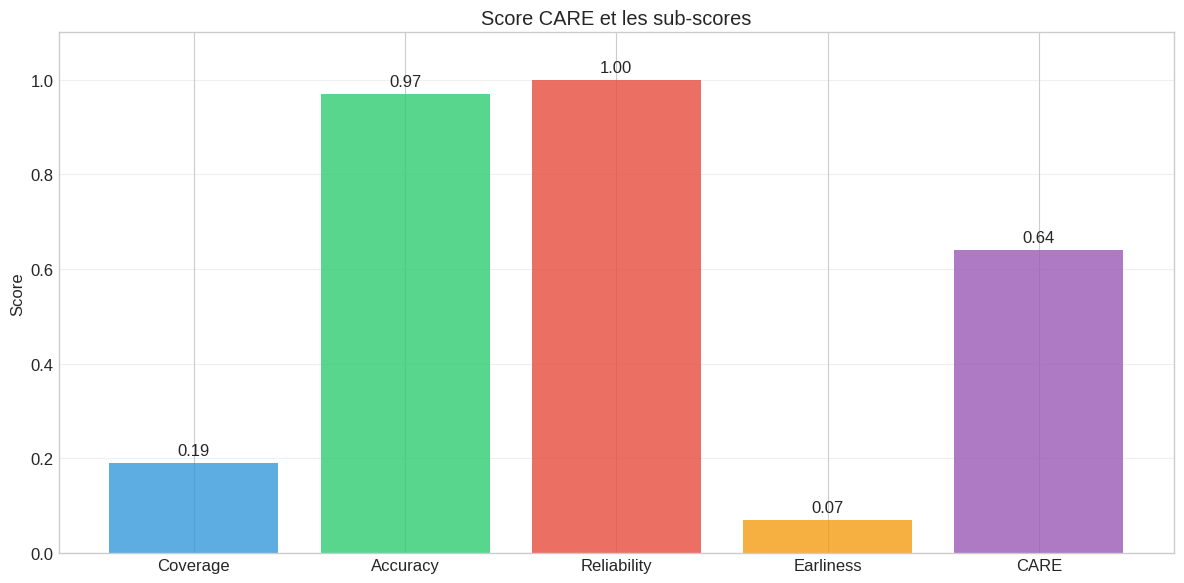

In [16]:
test_data = df[df['train_test'] == 'prediction'].copy()
test_data.reset_index(drop=True, inplace=True)

anomaly_results_no_pca = anomaly_results_no_pca.reset_index(drop=True)
care_scores = run_care_evaluation(
    df=df,
    anomaly_results=anomaly_results_no_pca,
    time_stamp_col='time_stamp',
    rename_col='timestamp',
    omega1=1.0,
    omega2=1.0,
    omega3=1.0,
    omega4=2.0
)



## Optimisation Optuna

In [ ]:
# import torch
# import joblib
# from pathlib import Path

# # Chemin vers le modèle sauvegardé
# model_path = Path(r'/content/drive/MyDrive/GDM5 project/output/raw_results/final_detector.pth')

# # Charger le détecteur complet
# detector = torch.load(model_path, weights_only=False)

# # Maintenant vous pouvez accéder à toutes les variables du détecteur:

# # 1. Accéder aux modèles
# autoencoder = detector.model  # Le modèle autoencoder
# re_predictor = detector.re_predictor  # Le prédicteur d'erreur de reconstruction

# # 2. Accéder aux hyperparamètres
# encoding_dim = detector.encoding_dim  # Dimension de la couche latente
# hidden_dim = detector.hidden_dim  # Dimension de la couche cachée
# gamma = detector.gamma  # Paramètre gamma pour le calcul du seuil d'anomalie
# threshold = detector.threshold.item() if detector.threshold is not None else None  # Seuil d'anomalie

# # 3. Accéder aux transformations de données
# scaler = detector.scaler  # Le scaler utilisé pour normaliser les données
# pca = detector.pca  # Le modèle PCA (si utilisé)

# # 4. Accéder aux méthodes du détecteur
# # Par exemple, pour détecter des anomalies sur de nouvelles données:
# # anomaly_results = detector.detect_anomalies(new_data, is_pca_data=False)

# # 5. Accéder aux résultats sauvegardés séparément
# results_path = Path(r'/content/drive/MyDrive/GDM5 project/output/raw_results/results.pkl')
# if results_path.exists():
#     results = joblib.load(results_path)

#     # Historiques d'entraînement
#     losses = results.get('losses', [])
#     validation_losses = results.get('validation_losses', [])

#     # Résultats d'anomalies
#     anomaly_results = results.get('anomaly_results', None)

#     # Top sensors
#     top_sensors = results.get('top_sensors', None)

#     print("Variables chargées avec succès:")
#     print(f"- Dimension d'encodage: {encoding_dim}")
#     print(f"- Seuil d'anomalie: {threshold}")
#     print(f"- Nombre d'époques d'entraînement: {len(losses)}")
#     if anomaly_results is not None:
#         print(f"- Nombre d'anomalies détectées: {anomaly_results['anomaly'].sum()}")
#     if top_sensors is not None:
#         print(f"- Top capteur: {top_sensors.index[0]}")
# else:
#     print("Fichier de résultats non trouvé.")

Variables chargées avec succès:
- Dimension d'encodage: 23
- Seuil d'anomalie: 1.082291841506958
- Nombre d'époques d'entraînement: 30
- Nombre d'anomalies détectées: 6525
- Top capteur: sensor_5_min


In [ ]:
import os
import shutil

def clean_checkpoint_directory(checkpoint_dir='/content/drive/MyDrive/GDM5 project/output/epochs', remove_all=False):
    """
    Cleans the checkpoint directory by removing epoch files or the entire directory.

    Args:
        checkpoint_dir: The path to the checkpoint directory (default: 'analysis_checkpoints').
        remove_all: If True, removes the entire directory; otherwise, removes only epoch files (default: False).
    """
    global_epoch_dir = os.path.join(checkpoint_dir, 'global_epoch')  # Path to the 'global_epoch' subdirectory

    if remove_all:
        # Remove the entire directory and its contents
        if os.path.exists(checkpoint_dir):
            shutil.rmtree(checkpoint_dir)
            print(f"Directory '{checkpoint_dir}' removed successfully.")
        else:
            raise FileNotFoundError(f"Directory '{checkpoint_dir}' not found.")
    else:
        # Remove only the epoch files in both directories
        for directory in [checkpoint_dir, global_epoch_dir]:
            if os.path.exists(directory):
                for filename in os.listdir(directory):
                    if filename.endswith('.pth'):
                        file_path = os.path.join(directory, filename)
                        os.remove(file_path)
                print(f"Epoch files in '{directory}' removed successfully.")
            #else:
                # You might want to handle the case where 'global_epoch' doesn't exist
                # For example, print a message or skip it silently
                #print(f"Directory '{directory}' not found.")

# Example usage:
# To remove only epoch files:
# clean_checkpoint_directory()

Epoch files in '/content/drive/MyDrive/GDM5 project/output/epochs' removed successfully.


# Principal Component Analysis

In [ ]:
# def preprocess_data(df):
#     """
#     Prétraitement des données: sélection et normalisation des capteurs

#     Args:
#         df: DataFrame contenant les données des capteurs

#     Returns:
#         X_scaled: Données normalisées
#         sensor_columns: Noms des colonnes sélectionnées
#     """
#     # Sélection des colonnes pertinentes (capteurs uniquement)
#     sensor_columns = [col for col in df.columns if any(x in col for x in
#                     ['sensor', 'wind_speed', 'power'])]

#     print(f"Nombre de capteurs sélectionnés: {len(sensor_columns)}")

#     # Vérification et nettoyage des données
#     X = df[sensor_columns].copy()

#     # Remplacer les valeurs infinies par NaN
#     X.replace([np.inf, -np.inf], np.nan, inplace=True)

#     # Fill NaN with column means
#     X.fillna(X.mean(), inplace=True)

#     scaler = StandardScaler()

#     # Normalisation des caractéristiques
#     X_scaled = scaler.fit_transform(X)

#     return X_scaled, sensor_columns

In [ ]:
# Chargement et préparation des données
train_data = df[(df['train_test'] == 'train') & (df['status_id'] == 'normal')]
train_data, validation_data = train_test_split(train_data, test_size=0.25, random_state=42)
test_data = df[df['train_test'] == 'prediction']
detector = WindTurbineAnomalyDetector()
scaled_data, sensor_columns, detector.scaler = preprocess_data(
            train_data,
            is_pca_data=False,
            scaler=None
        )

Utilisation de: cuda
Nombre de capteurs sélectionnés: 81


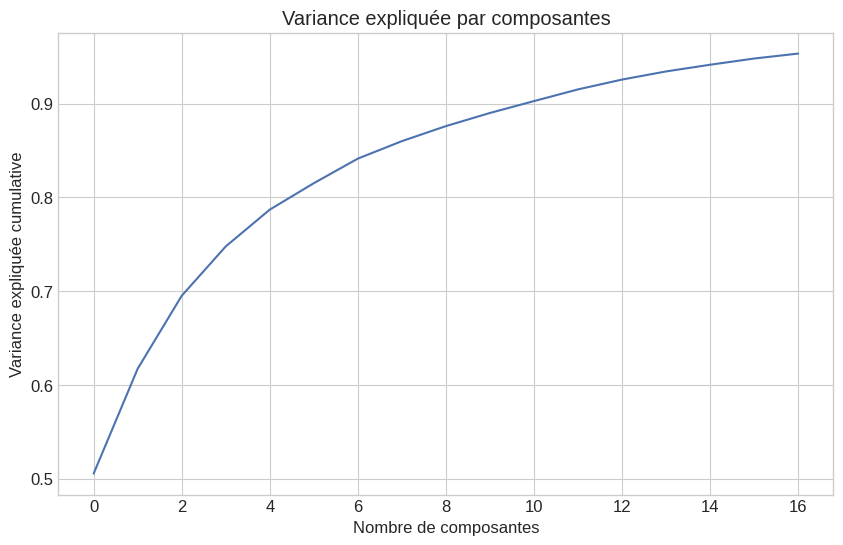

In [ ]:
# Application de l'ACP
pca = PCA(n_components=0.95)  # Conserver 95% de la variance
principal_components = pca.fit_transform(scaled_data)

# Visualisation de la variance expliquée
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulative')
plt.title('Variance expliquée par composantes')
plt.show()


   - The first 2-3 components already capture around 70% of the variance.
   - The curve flattens significantly after 6-8 components.
   - The 16 components reach 95% of the explained variance.

not recommend using all 16 components directly -- >

   - The last components (9-16) add very little extra information.
   - They might represent noise rather than meaningful patterns.

   - Anomalies are often better detected in a reduced but meaningful space.
   - Too many dimensions can dilute anomaly signals.

---- >

   - Using 6-8 principal components, which capture around 85% of the variance.
   - Adjusting your autoencoder accordingly.

---->
   - Better signal-to-noise ratio.
   - Reduced model complexity.
   - Focus on the most significant patterns.
   - Faster training time.
   - Improved generalization.


<ipython-input-22-8d2948a22671>:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = cmap(norm(distances[i]))


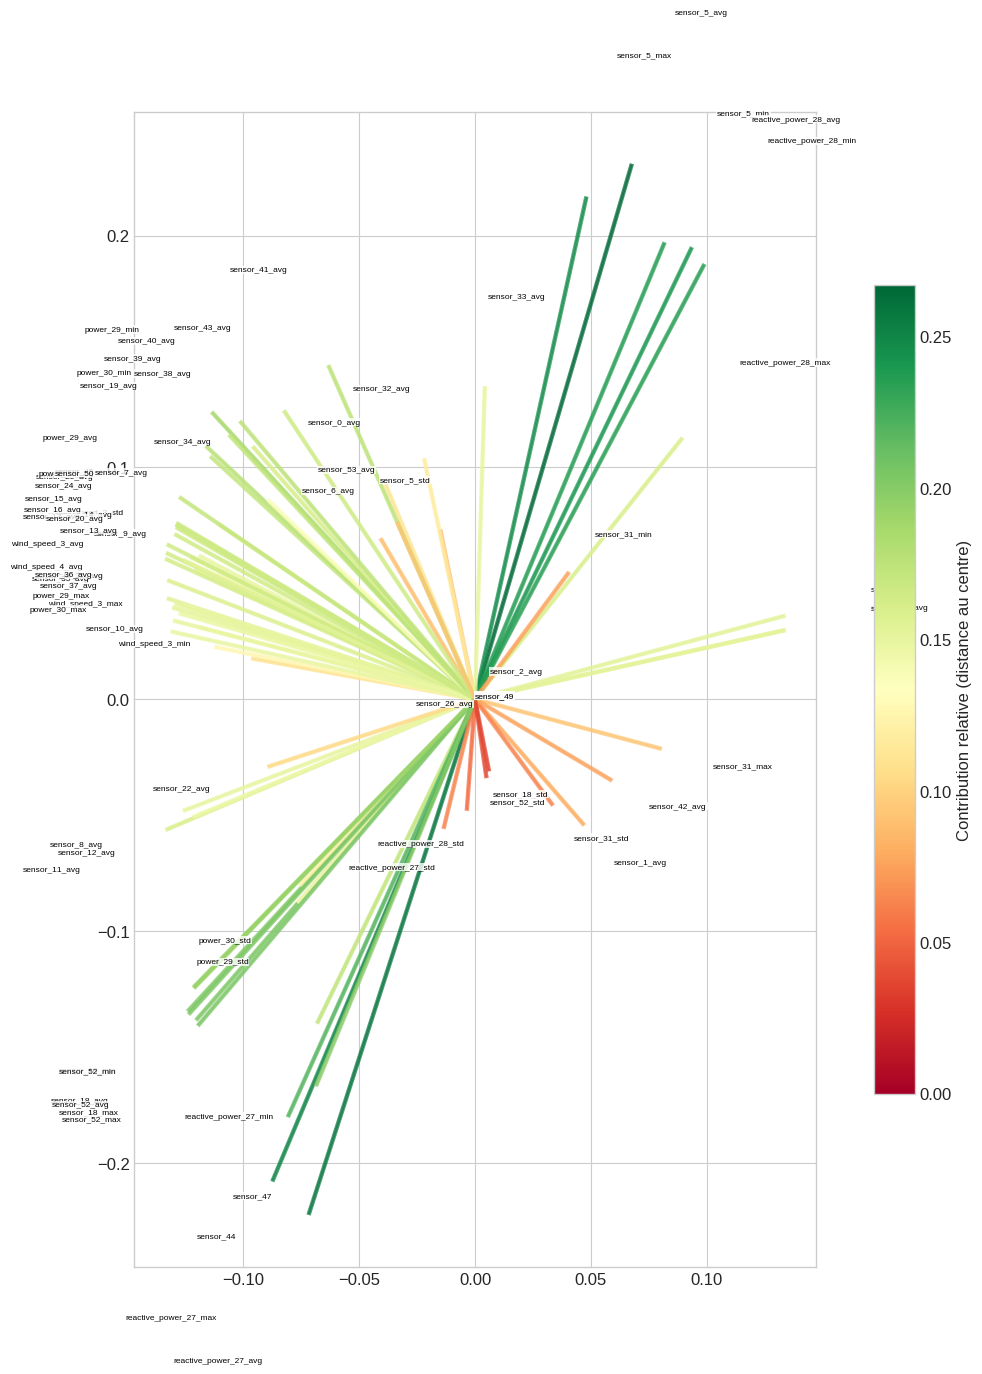

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df[sensor_columns].columns
)


# Calcul de la distance au centre pour chaque variable
distances = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
norm = plt.Normalize(vmin=distances.min(), vmax=distances.max())
cmap = plt.cm.RdYlGn  # Dégradé rouge (proche) à vert (loin)

# Création du cercle de corrélation
fig, ax = plt.subplots(figsize=(15, 15))  # <--- Change 1
ax.set_aspect('equal')  # <--- Change 2

for i, (pc1, pc2) in enumerate(zip(loadings['PC1'], loadings['PC2'])):
    color = cmap(norm(distances[i]))
    plt.arrow(0, 0,
              pc1 * 0.9,
              pc2 * 0.9,
              head_width=0,
              color=color,
              alpha=0.7,
              linewidth=1.5)

    # Positionnement des labels en noir avec meilleure lisibilité
    offset = 1.15
    plt.text(pc1 * offset,
             pc2 * offset,
             loadings.index[i],
             fontsize=6,  # Taille de police réduite
             color='black',
             ha='left' if pc1 >= 0 else 'right',  # Alignement selon la position
             va='bottom' if pc2 >= 0 else 'top',
             rotation=0,  # Sans rotation
             bbox=dict(facecolor='white',
                      alpha=0.8,
                      edgecolor='none',
                      pad=0.5))  # Fond blanc semi-transparent

# Ajout de la légende de couleur
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.7)  # <--- Change 4
cbar.set_label('Contribution relative (distance au centre)', fontsize=12)

# Interprétation du cercle de corrélation



1. **Variables groupées** : Les variables qui pointent dans des directions similaires sont positivement corrélées entre elles. Par exemple, on voit plusieurs capteurs regroupés dans le quadrant inférieur gauche (sensor_40_avg, sensor_41_avg, sensor_43_avg).

2. **Variables opposées** : Les variables qui pointent dans des directions opposées sont négativement corrélées. Par exemple, sensor_31_max et sensor_12_avg semblent avoir une relation inverse.

3. **Proximité au cercle** : Les variables proches du cercle extérieur sont bien représentées par ces deux composantes principales. Les variables comme sensor_48, sensor_31_max et reactive_power_28_max sont particulièrement bien représentées.

4. **Proximité à l'origine** : Les variables proches du centre contribuent peu à ces deux composantes et sont moins bien expliquées par cette projection.

5. **Axe horizontal (PC1)** : Cet axe explique la plus grande partie de la variance. Il semble opposer les variables liées à la puissance réactive (reactive_power) et certains capteurs spécifiques.

6. **Axe vertical (PC2)** : Représentant 9.8% de la variance, cet axe semble distinguer différents groupes de capteurs.

## Groupes identifiables :

- **Groupe 1** (quadrant supérieur) : Variables liées à la puissance réactive et capteurs 44, 47
- **Groupe 2** (quadrant droit) : Capteurs 31, 48, 15
- **Groupe 3** (quadrant inférieur) : Plusieurs capteurs moyens (avg) et variables de puissance


In [143]:
detector_pca, anomaly_results_pca, top_sensors_pca, losses_pca, validation_losses_pca = run_analysis(use_pca=True)

Random seeds set to 42 for reproducibility




Train data shape: (7133, 88), columns: Index(['name_file', 'time_stamp', 'asset_id', 'id', 'train_test',
       'status_type_id', 'sensor_0_avg', 'sensor_1_avg', 'sensor_2_avg',
       'wind_speed_3_avg', 'wind_speed_4_avg', 'wind_speed_3_max',
       'wind_speed_3_min', 'wind_speed_3_std', 'sensor_5_avg', 'sensor_5_max',
       'sensor_5_min', 'sensor_5_std', 'sensor_6_avg', 'sensor_7_avg',
       'sensor_8_avg', 'sensor_9_avg', 'sensor_10_avg', 'sensor_11_avg',
       'sensor_12_avg', 'sensor_13_avg', 'sensor_14_avg', 'sensor_15_avg',
       'sensor_16_avg', 'sensor_17_avg', 'sensor_18_avg', 'sensor_18_max',
       'sensor_18_min', 'sensor_18_std', 'sensor_19_avg', 'sensor_20_avg',
       'sensor_21_avg', 'sensor_22_avg', 'sensor_23_avg', 'sensor_24_avg',
       'sensor_25_avg', 'sensor_26_avg', 'reactive_power_27_avg',
       'reactive_power_27_max', 'reactive_power_27_min',
       'reactive_power_27_std', 'reactive_power_28_avg',
     

<ipython-input-142-ca111358e9cd>:137: RuntimeWarning: Mean of empty slice.
  print(f"Vérification scaling - Moyenne train: {X_train.mean():.4f}, Écart-type: {X_train.std():.4f}")
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x0 and 16x6)

# Selection features with random forest


In [ ]:
# def load_detector_info(model_path: Path, results_path: Path, suffix: str = "") -> dict:
#     """
#     Charge le détecteur complet et les résultats sauvegardés, et retourne un dictionnaire
#     avec les clés suivantes :
#       - detector_{suffix}
#       - anomaly_results_{suffix}
#       - top_sensors_{suffix}
#       - losses_{suffix}
#       - validation_losses_{suffix}

#     Args:
#         model_path (Path): Chemin vers le modèle sauvegardé (.pth).
#         results_path (Path): Chemin vers le fichier de résultats (.pkl).
#         suffix (str): Suffixe à ajouter aux clés (par exemple "pca").

#     Returns:
#         dict: Dictionnaire contenant les variables avec les clés formatées.
#     """
#     import torch, joblib

#     # Charger le détecteur complet
#     detector = torch.load(model_path, weights_only=False)

#     # Charger les résultats sauvegardés s'ils existent
#     if results_path.exists():
#         results = joblib.load(results_path)
#         losses = results.get("losses", [])
#         validation_losses = results.get("validation_losses", [])
#         anomaly_results = results.get("anomaly_results", None)
#         top_sensors = results.get("top_sensors", None)
#     else:
#         losses = validation_losses = anomaly_results = top_sensors = None
#         print("Fichier de résultats non trouvé.")

#     # Créer un dictionnaire avec les clés formatées avec le suffixe
#     info = {
#         f"detector_{suffix}": detector,
#         f"anomaly_results_{suffix}": anomaly_results,
#         f"top_sensors_{suffix}": top_sensors,
#         f"losses_{suffix}": losses,
#         f"validation_losses_{suffix}": validation_losses,
#     }

#     print("Variables chargées avec succès:")
#     print(f"- Dimension d'encodage: {detector.encoding_dim}")
#     threshold = detector.threshold.item() if detector.threshold is not None else None
#     print(f"- Seuil d'anomalie: {threshold}")
#     print(f"- Nombre d'époques d'entraînement: {len(losses) if losses is not None else 'N/A'}")
#     if anomaly_results is not None:
#         print(f"- Nombre d'anomalies détectées: {anomaly_results['anomaly'].sum()}")
#     if top_sensors is not None:
#         print(f"- Top capteur: {top_sensors.index[0]}")

#     return info


In [ ]:
from pathlib import Path

model_path = Path(r'/content/drive/MyDrive/GDM5 project/output/pca_results/final_detector.pth')
results_path = Path(r'/content/drive/MyDrive/GDM5 project/output/pca_results/results.pkl')

info = load_detector_info(model_path, results_path, suffix="pca")
# Vous pouvez accéder aux variables ainsi :
detector_pca = info["detector_pca"]
anomaly_results_pca = info["anomaly_results_pca"]
top_sensors_pca = info["top_sensors_pca"]
losses_pca = info["losses_pca"]
validation_losses_pca = info["validation_losses_pca"]


Variables chargées avec succès:
- Dimension d'encodage: 5
- Seuil d'anomalie: 4.826455593109131
- Nombre d'époques d'entraînement: 28
- Nombre d'anomalies détectées: 14920


[Coverage Debug] TP=4397, FN=7098, FP=10523, Score=0.3089
[Accuracy Debug] TN=28575, FP=10523
[Reliability] Max Criticality: 305, Threshold: 72
[Reliability] Event Detected: 1, Real Event: 1
[Reliability] TP: 1, FN: 0, FP: 0, Score: 1.0000
{'coverage': np.float64(0.31), 'accuracy': np.float64(0.73), 'reliability': 1.0, 'earliness': np.float64(0.51), 'care': np.float64(0.66)}


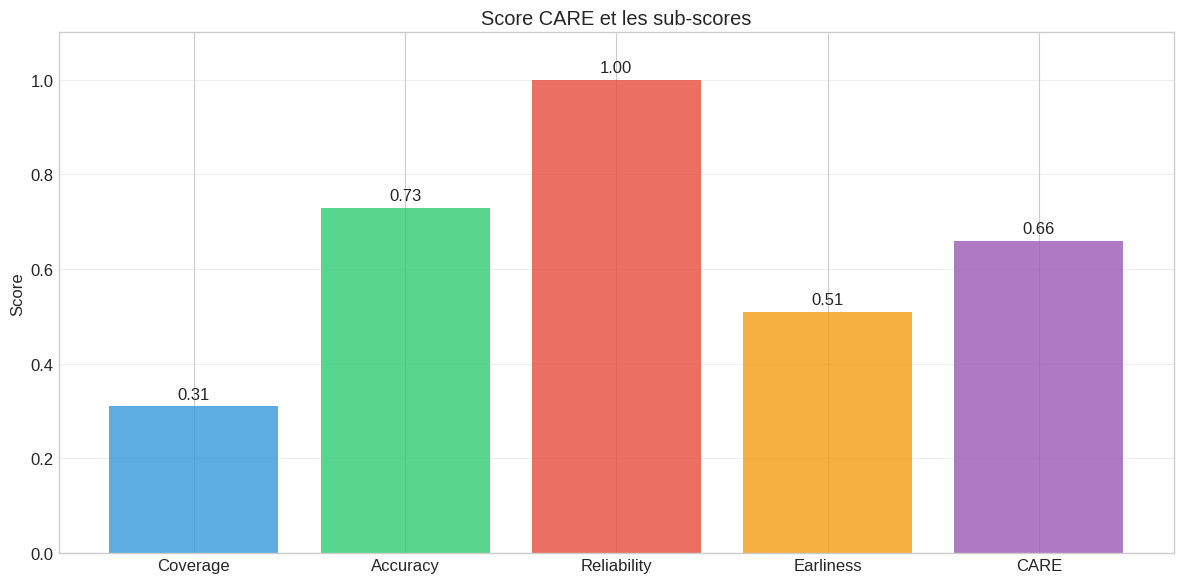

In [ ]:
# Réinitialiser les index pour assurer un alignement
test_data_aligned = test_data.reset_index(drop=True)
anomaly_results_aligned = anomaly_results_pca.reset_index(drop=True)

# Renommer la colonne "time_stamp" en "timestamp" dans le DataFrame test
test_data_aligned = test_data_aligned.rename(columns={'time_stamp': 'timestamp'})

# Ajouter la colonne timestamp à anomaly_results_aligned (si nécessaire)
anomaly_results_aligned['timestamp'] = test_data_aligned['timestamp'].values

# Maintenant, run_care_evaluation va trouver la colonne "timestamp"
care_scores = run_care_evaluation(
    df=test_data_aligned,
    anomaly_results=anomaly_results_aligned,
    train_test_col='train_test',
    time_stamp_col='timestamp',  # Le nom de la colonne temporelle dans df
    rename_col='timestamp',
    omega1=1.0,
    omega2=1.0,
    omega3=1.0,
    omega4=2.0
)


In [ ]:
def select_features_with_random_forest(data, target_column='status_id', n_features=20,
                                      n_estimators=100, max_depth=None, min_samples_split=2,
                                      min_samples_leaf=1, criterion='gini', max_features='sqrt',
                                      class_weight='balanced', random_state=42):
    """
    Utilise Random Forest pour sélectionner les features les plus importantes.

    Args:
        data: DataFrame contenant les données
        target_column: Colonne cible pour la classification
        n_features: Nombre de features à sélectionner
        n_estimators: Nombre d'arbres dans la forêt
        max_depth: Profondeur maximale des arbres
        min_samples_split: Nombre minimum d'échantillons requis pour diviser un nœud
        min_samples_leaf: Nombre minimum d'échantillons requis dans une feuille
        criterion: Fonction pour mesurer la qualité d'une division ('gini' ou 'entropy')
        max_features: Nombre de features à considérer lors de la recherche de la meilleure division
        class_weight: Poids associés aux classes
        random_state: État aléatoire pour la reproductibilité

    Returns:
        Liste des noms des features les plus importantes
    """
    from sklearn.ensemble import RandomForestClassifier

    # Préparation des données
    X = data.drop(columns=['time_stamp', 'train_test', target_column, 'asset_id', 'status_type_id'], errors='ignore')
    y = data[target_column].map({'normal': 0, 'not normal': 1})

    # Initialisation et entraînement du modèle avec les hyperparamètres spécifiés
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        max_features=max_features,
        class_weight=class_weight,
        random_state=random_state
    )
    rf.fit(X, y)

    # Récupération des importances des features
    feature_importances = pd.DataFrame({
        'feature': X.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)

    # Visualisation des importances
    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=feature_importances.head(n_features))
    plt.title(f'Top {n_features} Features les plus importantes (critère: {criterion})')
    plt.tight_layout()
    plt.show()

    # Sélection des features les plus importantes
    top_features = feature_importances.head(n_features)['feature'].tolist()

    # Affichage des métriques d'importance
    print(f"Somme des importances des {n_features} features sélectionnées: {feature_importances.head(n_features)['importance'].sum():.4f}")
    print(f"Pourcentage de l'importance totale: {feature_importances.head(n_features)['importance'].sum() / feature_importances['importance'].sum() * 100:.2f}%")

    return top_features, rf, feature_importances

In [ ]:
#drop columns name_file time_stamp asset_id id train_test status_type_id in df
df_random_forest = df.drop(columns=['name_file', 'time_stamp', 'asset_id', 'id', 'train_test',
       'status_type_id'])

In [ ]:
def save_important_features(features_gini, features_entropy, output_path):
    """Saves important features to the specified path."""
    os.makedirs(output_path, exist_ok=True)  # Create directory if it doesn't exist
    joblib.dump(features_gini, os.path.join(output_path, 'important_features_gini.pkl'))
    joblib.dump(features_entropy, os.path.join(output_path, 'important_features_entropy.pkl'))
    print(f"Important features saved to: {output_path}")

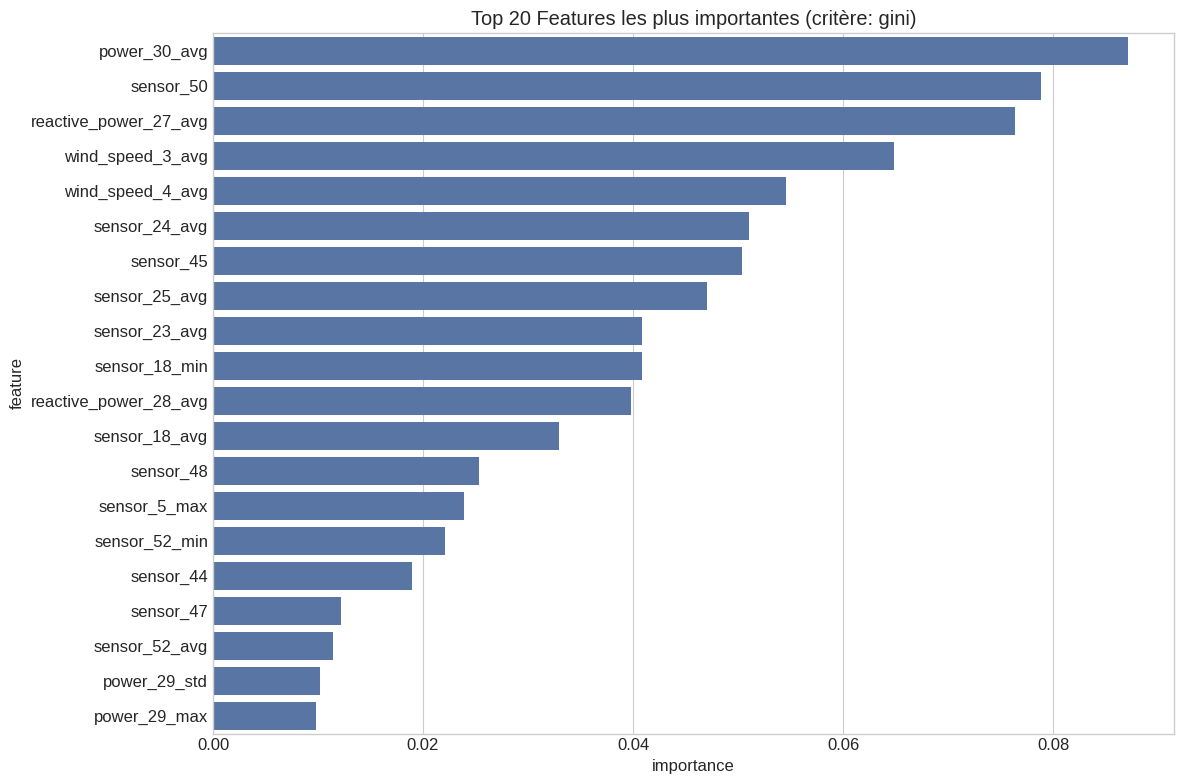

Somme des importances des 20 features sélectionnées: 0.7986
Pourcentage de l'importance totale: 79.86%


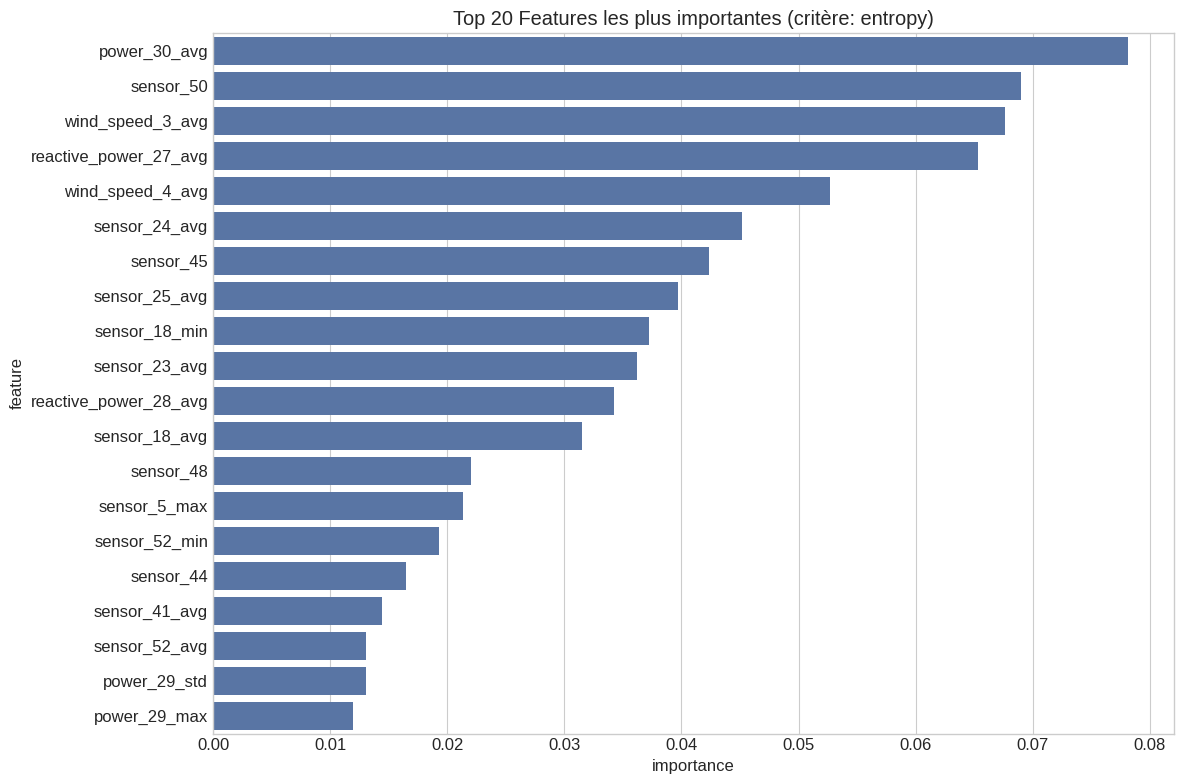

Somme des importances des 20 features sélectionnées: 0.7309
Pourcentage de l'importance totale: 73.09%
Features communes entre Gini et Entropy: 19/20
Features sélectionnées: ['power_30_avg', 'sensor_50', 'reactive_power_27_avg', 'wind_speed_3_avg', 'wind_speed_4_avg', 'sensor_24_avg', 'sensor_45', 'sensor_25_avg', 'sensor_23_avg', 'sensor_18_min', 'reactive_power_28_avg', 'sensor_18_avg', 'sensor_48', 'sensor_5_max', 'sensor_52_min', 'sensor_44', 'sensor_47', 'sensor_52_avg', 'power_29_std', 'power_29_max']
Important features saved to: /content/drive/MyDrive/GDM5 project/output/selection_features


In [ ]:
# Utiliser Gini (par défaut)
important_features_gini, rf_model_gini, importances_gini = select_features_with_random_forest(
    df_random_forest,
    n_features=20,
    criterion='gini',
    n_estimators=200,
    max_depth=15,
    min_samples_split=5
)

# Ou utiliser Entropy
important_features_entropy, rf_model_entropy, importances_entropy = select_features_with_random_forest(
    df_random_forest,
    n_features=20,
    criterion='entropy',
    n_estimators=200,
    max_depth=15,
    min_samples_split=5
)

# Comparer les résultats
common_features = set(important_features_gini).intersection(set(important_features_entropy))
print(f"Features communes entre Gini et Entropy: {len(common_features)}/{len(important_features_gini)}")

# Utiliser les features sélectionnées (par exemple, celles de Gini)
important_features = important_features_gini
print(f"Features sélectionnées: {important_features}")
# save in this path /content/drive/MyDrive/GDM5 project/output  important_features_gini and important_features_entropy
output_path = '/content/drive/MyDrive/GDM5 project/output/selection_features'
save_important_features(important_features_gini, important_features_entropy, output_path)

In [ ]:
df.columns

Index(['name_file', 'time_stamp', 'asset_id', 'id', 'train_test',
       'status_type_id', 'sensor_0_avg', 'sensor_1_avg', 'sensor_2_avg',
       'wind_speed_3_avg', 'wind_speed_4_avg', 'wind_speed_3_max',
       'wind_speed_3_min', 'wind_speed_3_std', 'sensor_5_avg', 'sensor_5_max',
       'sensor_5_min', 'sensor_5_std', 'sensor_6_avg', 'sensor_7_avg',
       'sensor_8_avg', 'sensor_9_avg', 'sensor_10_avg', 'sensor_11_avg',
       'sensor_12_avg', 'sensor_13_avg', 'sensor_14_avg', 'sensor_15_avg',
       'sensor_16_avg', 'sensor_17_avg', 'sensor_18_avg', 'sensor_18_max',
       'sensor_18_min', 'sensor_18_std', 'sensor_19_avg', 'sensor_20_avg',
       'sensor_21_avg', 'sensor_22_avg', 'sensor_23_avg', 'sensor_24_avg',
       'sensor_25_avg', 'sensor_26_avg', 'reactive_power_27_avg',
       'reactive_power_27_max', 'reactive_power_27_min',
       'reactive_power_27_std', 'reactive_power_28_avg',
       'reactive_power_28_max', 'reactive_power_28_min',
       'reactive_power_28_std', 'p

In [ ]:
#how to load important_features_gini
import joblib
import os

output_path = '/content/drive/MyDrive/GDM5 project/output/selection_features'
important_features_gini = joblib.load(os.path.join(output_path, 'important_features_gini.pkl'))
important_features_entropy = joblib.load(os.path.join(output_path, 'important_features_entropy.pkl'))

Random seeds set to 42 for reproducibility
Jeux de données train, val et test créés
Données d'entraînement: 644680 lignes
Données de validation: 214894 lignes
Données de test: 50593 lignes
Mode PCA: Désactivé
Utilisation de: cuda
Classe WindTurbineAnomalyDetector initialisée à 23 encoding dim
Nombre de capteurs sélectionnés: 20
Utilisation des données brutes (sans PCA)
Nombre de capteurs sélectionnés: 20
Nombre de capteurs sélectionnés: 20
Nombre de capteurs sélectionnés: 20
Entraînement avec données PCA: False
Vérification scaling - Moyenne train: -0.0000, Écart-type: 1.0000
Statistiques des données d'entraînement: Min=-10.6196, Max=15.3465, Moyenne=-0.0000, Écart-type=1.0000
Statistiques des données de validation: Min=-10.4444, Max=15.2326, Moyenne=-0.0006, Écart-type=1.0017
Début de l'entraînement...
Époque [1/30], Perte d'entraînement: 0.604928, Perte de validation: 0.596584
[Batch 6783] Changement brutal: 1079.3% (0.07 → 0.77)
[Batch 7863] Changement brutal: 1060.9% (0.04 → 0.44)


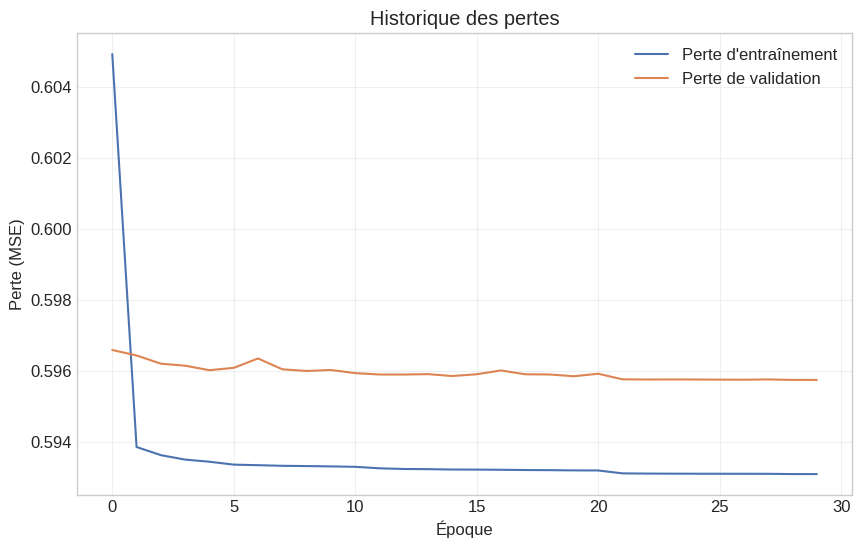

Nombre d'anomalies détectées: 50546
Pourcentage d'anomalies: 99.91%


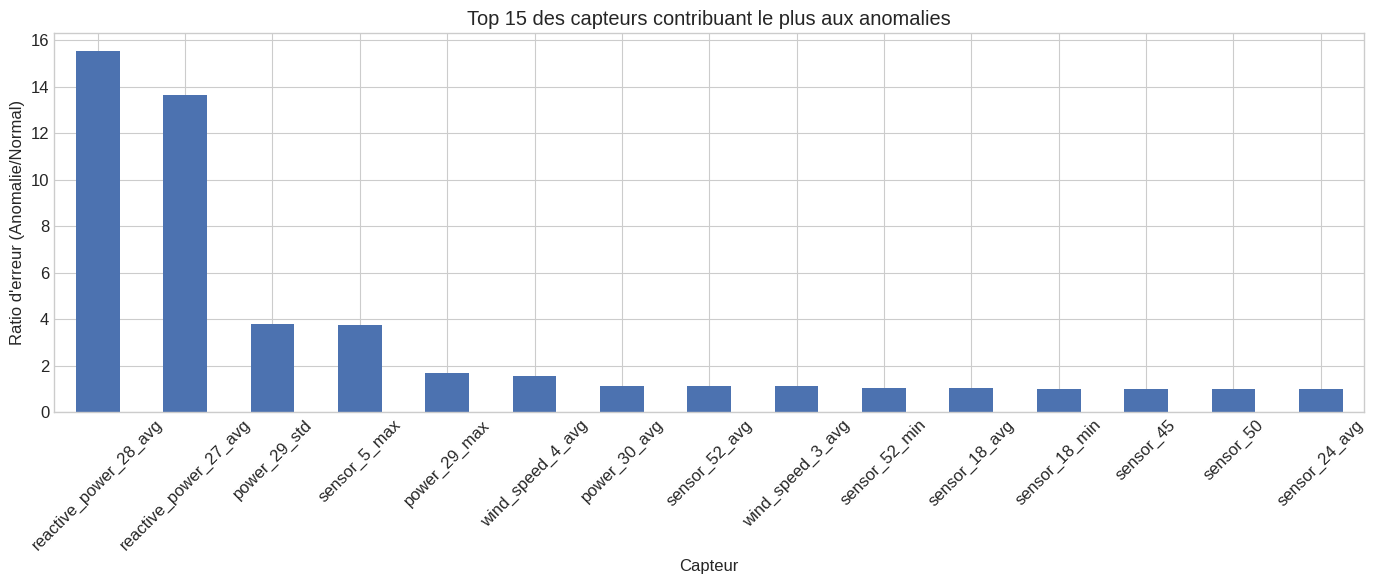

Sauvegarde du modèle final dans /content/drive/MyDrive/GDM5 project/output/raw_results/final_detector.pth
Modèle et résultats sauvegardés avec succès dans /content/drive/MyDrive/GDM5 project/output/raw_results


In [ ]:
# Liste des colonnes indispensables pour le pipeline
additional_columns = ['name_file', 'time_stamp', 'asset_id', 'id', 'train_test',
       'status_type_id','status_id']

# Créer la liste complète des colonnes à conserver
selected_columns = list(set(important_features_gini + additional_columns))

# Filtrer le DataFrame original pour ne conserver que ces colonnes
df_filtered = df[selected_columns].copy()

# On remplace la variable globale df par df_filtered
df = df_filtered

# Puis, lancez run_analysis normalement
detector, anomaly_results, top_sensors, losses, validation_losses = run_analysis(use_pca=False)


In [ ]:
# model_path = Path(r'/content/drive/MyDrive/GDM5 project/output/raw_results/final_detector.pth')
# results_path = Path(r'/content/drive/MyDrive/GDM5 project/output/raw_results/results.pkl')

# info = load_detector_info(model_path, results_path, suffix="random")
# # Vous pouvez accéder aux variables ainsi :
# detector_random = info["detector_random"]
# anomaly_results_random = info["anomaly_results_random"]
# top_sensors_random = info["top_sensors_random"]
# losses_random = info["losses_random"]
# validation_losses_random = info["validation_losses_random"]


Variables chargées avec succès:
- Dimension d'encodage: 23
- Seuil d'anomalie: 1.082291841506958
- Nombre d'époques d'entraînement: 30
- Nombre d'anomalies détectées: 6525
- Top capteur: sensor_5_min
[Coverage Debug] TP=2236, FN=9259, FP=4289, Score=0.2974
[Accuracy Debug] TN=34809, FP=4289
[Reliability] Max Criticality: 388, Threshold: 72
[Reliability] Event Detected: 1, Real Event: 1
[Reliability] TP: 1, FN: 0, FP: 0, Score: 1.0000
{'coverage': np.float64(0.3), 'accuracy': np.float64(0.89), 'reliability': 1.0, 'earliness': np.float64(0.23), 'care': np.float64(0.66)}


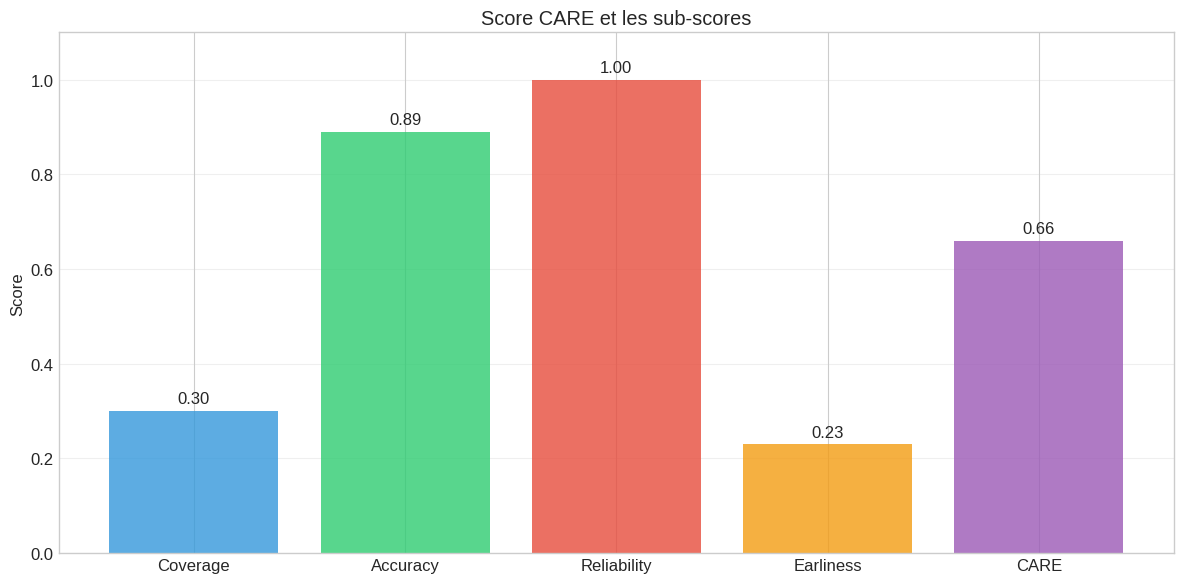

[Coverage Debug] TP=4397, FN=7098, FP=10523, Score=0.3089
[Accuracy Debug] TN=28575, FP=10523
[Reliability] Max Criticality: 305, Threshold: 72
[Reliability] Event Detected: 1, Real Event: 1
[Reliability] TP: 1, FN: 0, FP: 0, Score: 1.0000
{'coverage': np.float64(0.31), 'accuracy': np.float64(0.73), 'reliability': 1.0, 'earliness': np.float64(0.51), 'care': np.float64(0.66)}


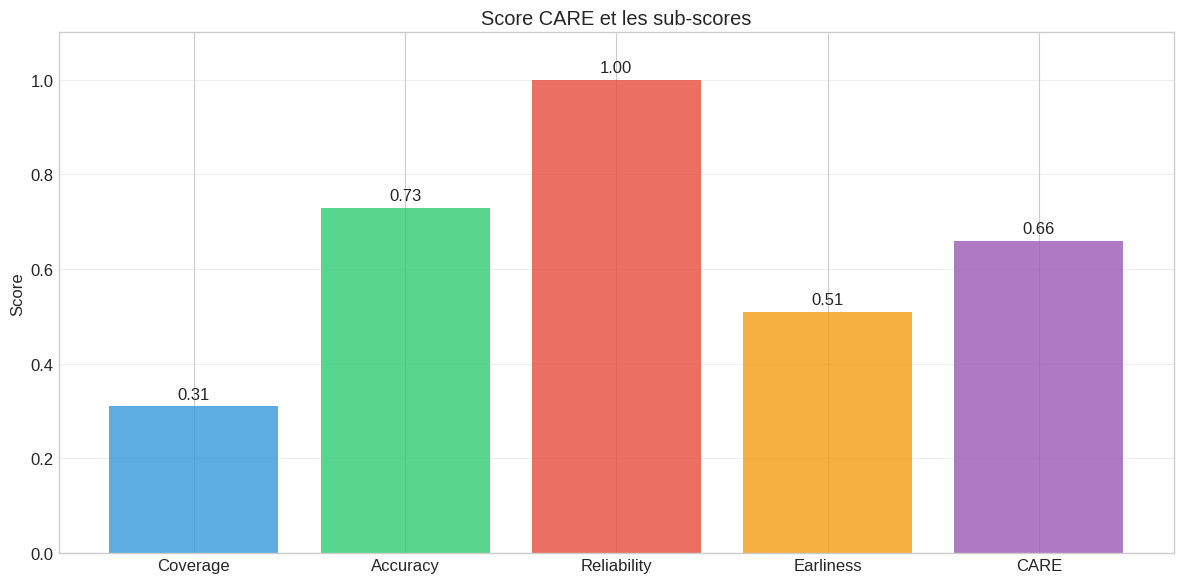

Variables chargées avec succès:
- Dimension d'encodage: 23
- Seuil d'anomalie: 2.9938535690307617
- Nombre d'époques d'entraînement: 30
- Nombre d'anomalies détectées: 50546
- Top capteur: reactive_power_28_avg
[Coverage Debug] TP=11489, FN=6, FP=39057, Score=0.2688
[Accuracy Debug] TN=41, FP=39057
[Reliability] Max Criticality: 11483, Threshold: 72
[Reliability] Event Detected: 1, Real Event: 1
[Reliability] TP: 1, FN: 0, FP: 0, Score: 1.0000
{'coverage': np.float64(0.27), 'accuracy': np.float64(0.0), 'reliability': 1.0, 'earliness': np.float64(1.0), 'care': np.float64(0.0)}


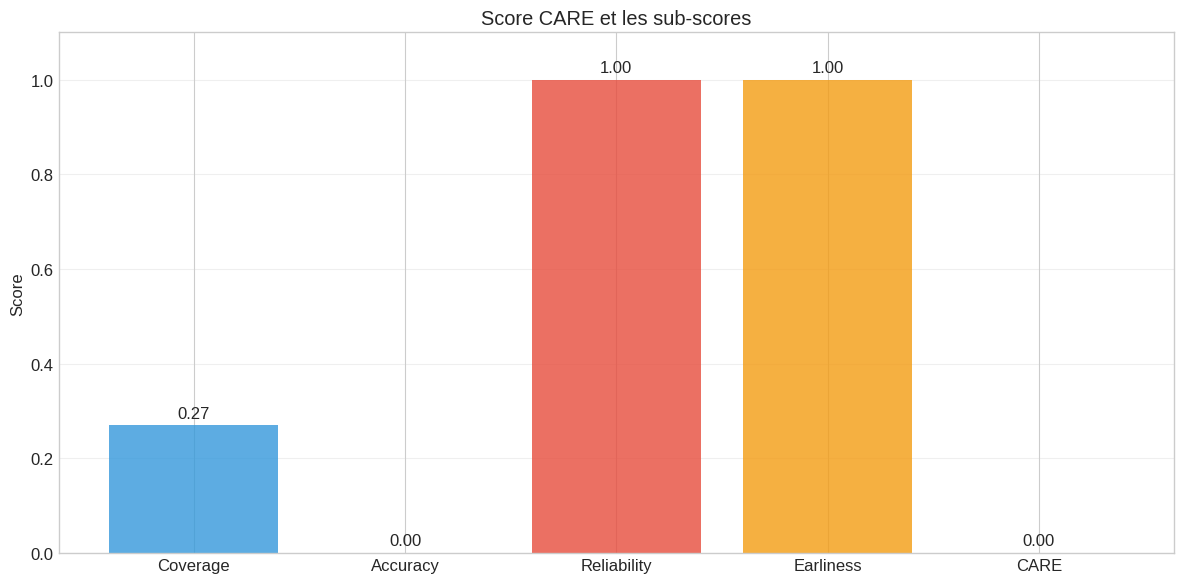

In [ ]:
# --- 1. CARE Scores pour les données brutes ---
model_path_raw = Path(r'/content/drive/MyDrive/GDM5 project/output/full_data/final_detector.pth')
results_path_raw = Path(r'/content/drive/MyDrive/GDM5 project/output/full_data/results.pkl')

info_raw = load_detector_info(model_path_raw, results_path_raw, suffix="")
# On récupère par exemple anomaly_results_no_pca dans info_raw
anomaly_results_raw = info_raw["anomaly_results_"]

# Calcul des CARE scores sur le df global (qui contient la colonne time_stamp, train_test, etc.)
care_scores_raw = run_care_evaluation(
    df=df,
    anomaly_results=anomaly_results_raw,
    train_test_col='train_test',
    time_stamp_col='time_stamp',
    rename_col='timestamp',
    omega1=1.0,
    omega2=1.0,
    omega3=1.0,
    omega4=2.0
)

# --- 2. CARE Scores pour le modèle PCA ---
# On suppose ici que anomaly_results_pca a déjà été obtenu (p. ex. par run_analysis en mode PCA)
# On réinitialise et renomme les index pour aligner la colonne temporelle.
test_data_aligned = test_data.reset_index(drop=True)
anomaly_results_pca_aligned = anomaly_results_pca.reset_index(drop=True)
# Renommer la colonne time_stamp en timestamp dans le DataFrame test
test_data_aligned = test_data_aligned.rename(columns={'time_stamp': 'timestamp'})
# Injecter la colonne timestamp dans anomaly_results_pca_aligned
anomaly_results_pca_aligned['timestamp'] = test_data_aligned['timestamp'].values

care_scores_pca = run_care_evaluation(
    df=test_data_aligned,
    anomaly_results=anomaly_results_pca_aligned,
    train_test_col='train_test',
    time_stamp_col='timestamp',
    rename_col='timestamp',
    omega1=1.0,
    omega2=1.0,
    omega3=1.0,
    omega4=2.0
)

# --- 3. CARE Scores pour la méthode avec sélection de features (Random Forest) ---
# Réinitialiser les index du DataFrame global et de anomaly_results_random
model_path_rand = Path(r'/content/drive/MyDrive/GDM5 project/output/raw_results/final_detector.pth')
results_path_rand = Path(r'/content/drive/MyDrive/GDM5 project/output/raw_results/results.pkl')

info_rand = load_detector_info(model_path_rand, results_path_rand, suffix="random")
anomaly_results_rand = info_rand["anomaly_results_random"]
df_aligned = test_data.reset_index(drop=True)
anomaly_results_aligned = anomaly_results_rand.reset_index(drop=True)

# Si nécessaire, ajouter une colonne de timestamp dans anomaly_results_rand_aligned à partir de df_aligned
if 'time_stamp' in df_aligned.columns:
    # Vous pouvez renommer "time_stamp" en "timestamp" dans df_aligned
    df_aligned = df_aligned.rename(columns={'time_stamp': 'timestamp'})
    anomaly_results_rand_aligned['timestamp'] = df_aligned['timestamp'].values

# Maintenant, appelez run_care_evaluation avec ces DataFrames alignés
care_scores_rand = run_care_evaluation(
    df=df_aligned,
    anomaly_results=anomaly_results_rand_aligned,
    train_test_col='train_test',
    time_stamp_col='timestamp',  # Le nom de la colonne temporelle dans df_aligned
    rename_col='timestamp',
    omega1=1.0,
    omega2=1.0,
    omega3=1.0,
    omega4=2.0
)


CARE Scores par méthode :
                Coverage  Accuracy  Reliability  Earliness  CARE
Données Brutes      0.30      0.89          1.0       0.23  0.66
PCA                 0.31      0.73          1.0       0.51  0.66
Selection RF        0.27      0.00          1.0       1.00  0.00


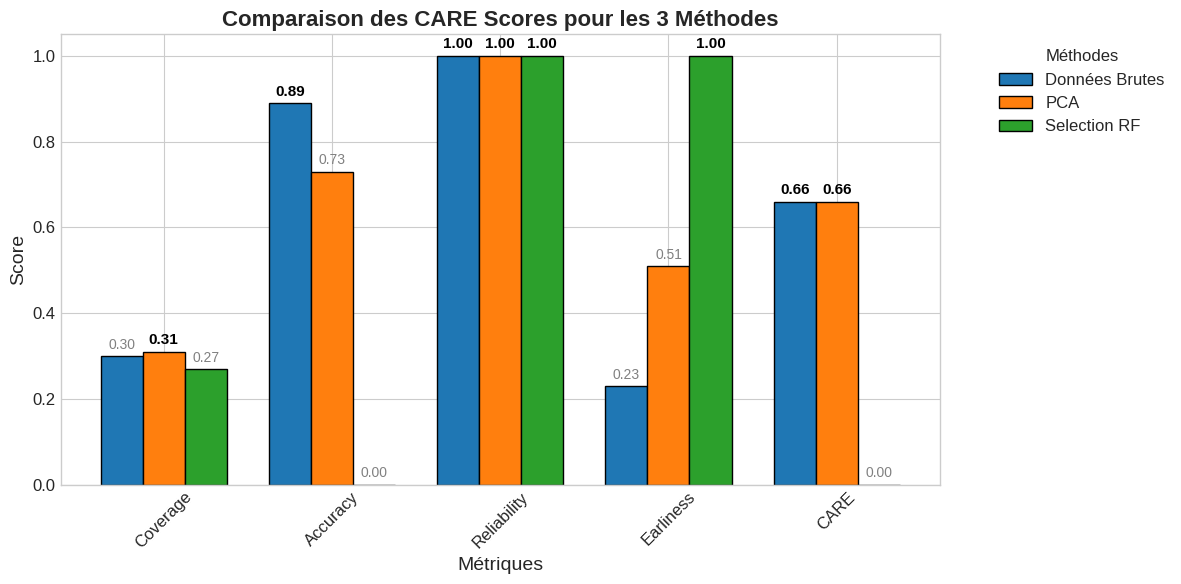

In [ ]:
# Supposons que care_scores_raw, care_scores_pca et care_scores_rand
# sont des dictionnaires retournés par run_care_evaluation de la forme :
# {'coverage': 0.3, 'accuracy': 0.89, 'reliability': 1.0, 'earliness': 0.23, 'care': 0.66}

# Construction du DataFrame des scores CARE pour les 3 méthodes
df_scores = pd.DataFrame({
    'Données Brutes': care_scores_raw,
    'PCA': care_scores_pca,
    'Selection RF': care_scores_rand
}).T

# Réorganiser l'ordre des colonnes si besoin
df_scores = df_scores[['coverage', 'accuracy', 'reliability', 'earliness', 'care']]

# Renommer les colonnes pour une meilleure lisibilité
metric_labels = {
    'coverage': 'Coverage',
    'accuracy': 'Accuracy',
    'reliability': 'Reliability',
    'earliness': 'Earliness',
    'care': 'CARE'
}
df_scores.rename(columns=metric_labels, inplace=True)

# Affichage du DataFrame pour vérification
print("CARE Scores par méthode :")
print(df_scores)

# Préparation du graphique
methods = df_scores.index.tolist()         # ex. ['Données Brutes', 'PCA', 'Selection RF']
metrics = df_scores.columns.tolist()         # ex. ['Coverage', 'Accuracy', 'Reliability', 'Earliness', 'CARE']
N = len(metrics)
ind = np.arange(N)
width = 0.25  # largeur de chaque barre

# Palette de couleurs harmonieuse pour 3 méthodes
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # bleu, orange, vert

# Calculer la meilleure valeur pour chaque métrique (max)
max_values = df_scores.max(axis=0)

fig, ax = plt.subplots(figsize=(12, 6))

# Tracer les barres pour chaque méthode
for i, method in enumerate(methods):
    values = df_scores.loc[method].values.astype(float)
    positions = ind + i * width - (width * (len(methods) - 1) / 2)
    bars = ax.bar(positions, values, width, label=method, color=colors[i],
                  edgecolor='black', linewidth=1)

    # Annoter chaque barre (mettre en gras la valeur si elle est la meilleure pour cette métrique)
    for pos, val, metric in zip(positions, values, metrics):
        if np.isclose(val, max_values[metric], atol=1e-4):
            ax.text(pos, val + 0.01, f'{val:.2f}', ha='center', va='bottom',
                    fontweight='bold', color='black', fontsize=11)
        else:
            ax.text(pos, val + 0.01, f'{val:.2f}', ha='center', va='bottom',
                    fontsize=10, color='gray')

# Paramétrage du graphique
ax.set_title("Comparaison des CARE Scores pour les 3 Méthodes", fontsize=16, fontweight='bold')
ax.set_ylabel("Score", fontsize=14)
ax.set_xlabel("Métriques", fontsize=14)
ax.set_xticks(ind)
ax.set_xticklabels(metrics, rotation=45, fontsize=12)
ax.legend(title="Méthodes", fontsize=12, title_fontsize=12, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


# Hyperparameters optimisation of the autoencoder with care score objective function

In [ ]:
import optuna
from optuna.trial import Trial

In [ ]:
def objective(trial: Trial):
    # Hyperparamètres à optimiser
    encoding_dim = trial.suggest_int('encoding_dim', 16, 32)
    hidden_dim = trial.suggest_int('hidden_dim', 16, 32)
    gamma = trial.suggest_float('gamma', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # Créer et entraîner le modèle avec les hyperparamètres suggérés
    detector = WindTurbineAnomalyDetector(
        encoding_dim=encoding_dim,
        hidden_dim=hidden_dim,
        gamma=gamma
    )

    # Entraînement
    detector.train(train_data, validation_data,
                  epochs=50,  # Réduire pour l'optimisation
                  batch_size=64,
                  learning_rate=learning_rate)

    # Entraîner le RE Predictor
    detector.train_re_predictor(train_data, validation_data)

    # Détecter les anomalies
    anomaly_results = detector.detect_anomalies(test_data)

    # Calculer le score CARE
    care_evaluator = CAREScore(omega1=1.0, omega2=1.0, omega3=1.0, omega4=2.0)
    care_scores = care_evaluator.calculate_care_score(test_data, anomaly_results)

    # Retourner le score CARE global à maximiser
    return care_scores['care']

# Créer une étude Optuna
train_data = df[(df['train_test'] == 'train') & (df['status_id'] == 'normal')]
train_data, validation_data = train_test_split(train_data, test_size=0.25, random_state=42)
test_data = df[df['train_test'] == 'prediction']

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)  # Ajuster le nombre d'essais selon vos besoins

# Afficher les meilleurs résultats
print("Meilleurs hyperparamètres trouvés:")
print(study.best_params)
print(f"Meilleur score CARE: {study.best_value:.4f}")

# Créer le modèle final avec les meilleurs hyperparamètres
best_detector = WindTurbineAnomalyDetector(
    encoding_dim=study.best_params['encoding_dim'],
    hidden_dim=study.best_params['hidden_dim'],
    gamma=study.best_params['gamma']
)

# # Entraîner le modèle final avec les meilleurs hyperparamètres
# best_detector.train(train_data, validation_data,
#                    epochs=300,  # Augmenter pour l'entraînement final
#                    batch_size=64,
#                    learning_rate=study.best_params['learning_rate'])

# # Entraîner le RE Predictor final
# best_detector.train_re_predictor(train_data, validation_data)

# # Évaluer les performances finales
# final_results = best_detector.detect_anomalies(test_data)
# final_care_scores = care_evaluator.calculate_care_score(test_data, final_results)
# final_care_scores = {k: round(v, 4) for k, v in final_care_scores.items()}
# print("\nScores finaux avec les meilleurs hyperparamètres:")
# for metric, value in final_care_scores.items():
#     print(f"{metric.capitalize()}: {value}")